# Phase 3 Step 2a — 종목별 LSTM 학습 (`02a_phase15_stockwise_extended.ipynb`)

> **목적**: Phase 1.5 v8 Performance-Weighted Ensemble 을 17 년 (2009~2025) **전체 S&P 500 universe** (~624 종목) 에
>          4-way 병렬 (RTX 4090 24GB) 로 학습·예측.

## 모델 구성 (Phase 1.5 v8 일관)

- **LSTM v4** (3ch_vix: rv_d, rv_w, rv_m + vix_log, IS=1250, embargo=63, hidden=32)
- **HAR-RV** (1d, 5d, 22d 이동평균 선형 회귀)
- **Ensemble** = Performance-Weighted (Diebold-Pauly rolling)

## 진행 상황 가시화 (재설계, 2026-04-29)

- `tqdm.auto` 진행 막대 (notebook + CMD 양쪽)
- 종목 완료마다 ETA·경과시간 출력 (`flush=True`)
- 매 20 종목마다 `ensemble_predictions_partial.csv` 중간 저장

## 실행 전 확인

1. `01_universe_extended.ipynb` 완료 (`universe_full_history.csv` + `daily_panel.csv`, 624 종목)
2. RTX 4090 24GB GPU 가용
3. CUDA + PyTorch 정상

## 산출물

| 파일 | 내용 |
|---|---|
| `data/ensemble_predictions_stockwise.csv` | 종목별 예측 (date, ticker, y_pred_lstm, y_pred_har, y_pred_ensemble, y_true) |

## 예상 시간

- **624 종목 × 4-way 병렬 (RTX 4090)**: 약 3~5 시간
- 8-way 대비 4-way: CUDA 컨텍스트 overhead ↓, 동일 또는 더 빠름

## 셀 구성

| § | 내용 |
|---|---|
| §1 | 환경 + 경로 |
| §2 | GPU 환경 확인 |
| §3 | 4-way 병렬 학습 실행 |
| §4 | 결과 검증 (RMSE 분포, best model 분포) |
| §5 | Phase 2 결과 비교 (공통 종목) |

## §1. 환경 부트스트랩

In [1]:
%load_ext autoreload
%autoreload 2

import sys, time
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.setup import bootstrap, DATA_DIR, OUTPUTS_DIR

font_used = bootstrap()

OUT_DIR = OUTPUTS_DIR / '02a_v2_stockwise'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'OUT_DIR: {OUT_DIR}')

  Phase 3 Robust Extensions — 환경 부트스트랩 완료
  한글 폰트   : Malgun Gothic
  시드        : 42
  데이터 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data
  Phase 1.5  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility
  Phase 2    : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration
OUT_DIR: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\outputs\02a_v2_stockwise


## §2. GPU 환경 확인

In [2]:
import torch

print('=== GPU 환경 ===')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    free_mem = (torch.cuda.get_device_properties(0).total_memory
                - torch.cuda.memory_allocated(0)) / 1e9
    print(f'Total VRAM: {total_mem:.1f} GB')
    print(f'Free  VRAM: {free_mem:.1f} GB')
    assert free_mem >= 3.0, f'VRAM 부족: {free_mem:.1f} GB < 3 GB'
    print('✅ GPU 조건 충족')
else:
    print('⚠️ CPU 모드 (매우 느림)')

=== GPU 환경 ===
PyTorch: 2.11.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4090
Total VRAM: 25.8 GB
Free  VRAM: 25.8 GB
✅ GPU 조건 충족


## §3. 8-way 병렬 학습 (V4_BEST_CONFIG, 전체 S&P 500)

`run_ensemble_for_universe_parallel()`:
- `n_workers=8` → CPU 병목 환경에서 최대 throughput
  - VRAM: 8 워커 × ~800MB = 6.4GB (24GB 중 여유)
- `tqdm.auto` 진행 막대 + 종목별 완료 로그 (실시간, `flush=True`)
- 매 20 종목마다 `ensemble_predictions_partial.csv` 중간 저장
- 학습 시간: 약 2~3 시간 (624 종목 / 8 workers / 종목당 ~100~120초)

> 💡 노트북에서 실행 시 진행률이 실시간 표시됩니다 (tqdm + flush).
> CMD `nbconvert` 실행 시에도 동일하게 출력됩니다.

In [3]:
from scripts.volatility_ensemble import run_ensemble_for_universe_parallel, V4_BEST_CONFIG

print('=== 하이퍼파라미터 ===')
for k, v in V4_BEST_CONFIG.items():
    print(f'  {k}: {v}')

=== 하이퍼파라미터 ===
  input_channels: 3ch_vix
  hidden_size: 32
  num_layers: 1
  dropout: 0.3
  lr: 0.001
  weight_decay: 0.001
  loss_type: mse
  huber_delta: 0.01
  max_epochs: 50
  early_stop_patience: 10
  lr_patience: 5
  lr_factor: 0.5
  batch_size: 64
  is_len: 1250
  seq_len: 63
  embargo: 63
  oos_len: 21
  step: 21
  window: 21
  har_w: 5
  har_m: 22


In [4]:
# 데이터 확인 (전체 S&P 500 universe)
panel_path = DATA_DIR / 'daily_panel.csv'
universe_path = DATA_DIR / 'universe_full_history.csv'  # ⭐ 624 종목 universe

assert panel_path.exists(), f'panel 없음: {panel_path}'
assert universe_path.exists(), f'universe 없음: {universe_path}'

panel_info = pd.read_csv(panel_path, usecols=['date', 'ticker'], parse_dates=['date'])
uni_info = pd.read_csv(universe_path)
print(f'panel: {len(panel_info):,} 행, {panel_info["ticker"].nunique()} 종목')
print(f'universe: {uni_info["ticker"].nunique()} unique 종목 (전체 S&P 500 모드)')

panel: 3,395,442 행, 646 종목
universe: 809 unique 종목 (전체 S&P 500 모드)


In [5]:
# §1.5 Panel Forward 확장 (1회 실행, 재실행 시 자동 skip)
# ⭐ 2026-05-01 추가: Panel 끝점을 forward 확장 → 마지막 fold y_true 채움
#    LSTM 의 y_true = 다음 21일 변동성 → panel 끝점 부족 시 마지막 1개월 학습 누락
#    이 셀 1회 실행 → daily_panel.csv, market_data.csv, vix_daily.csv 갱신
from scripts.universe_extended import extend_panel_forward

PANEL_END_DATE = '2026-04-30'   # ⭐ 원하는 panel 끝점

stats = extend_panel_forward(
    end_date=PANEL_END_DATE,
    backup=True,        # 기존 파일 .bak 백업
    verbose=True,
)
print(f'\n📊 Panel: {stats["panel_old_max"]} → {stats["panel_new_max"]}')
print(f'📊 추가 행: {stats["n_added_rows"]:+,d}')
print('\n다음 단계: Cell 8 (학습 셀) 의 INCREMENTAL_TRAIN=True 확인 후 실행')

  Panel Forward 확장: end_date = 2026-04-30
  기존 panel: 3,395,442 rows, max date = 2026-04-30
  ⚡ Panel 이 이미 2026-04-30 까지 → 확장 불필요 (end=2026-04-30)

📊 Panel: 2026-04-30 00:00:00 → 2026-04-30 00:00:00
📊 추가 행: +0

다음 단계: Cell 8 (학습 셀) 의 INCREMENTAL_TRAIN=True 확인 후 실행


In [6]:
import pandas as pd
panel = pd.read_csv('data/daily_panel.csv', parse_dates=['date'])
print(f'panel max date: {panel["date"].max()}')
print(f'2026-01 unique dates: {panel[panel["date"] >= "2026-01-01"]["date"].nunique()}')
print(f'2026-01 unique tickers: {panel[panel["date"] >= "2026-01-01"]["ticker"].nunique()}')
print(f'2026-04 unique tickers: {panel[panel["date"] >= "2026-04-01"]["ticker"].nunique()}')
# 기대:
#   panel max date = 2026-04-30
#   2026-01 unique dates = ~20 (영업일)
#   2026-01 unique tickers = 622
#   2026-04 unique tickers = 622

panel max date: 2026-04-30 00:00:00
2026-01 unique dates: 82
2026-01 unique tickers: 622
2026-04 unique tickers: 621


In [7]:
import pandas as pd
panel = pd.read_csv('data/daily_panel.csv', parse_dates=['date'])
jan_tickers = set(panel[panel['date'] >= '2026-01-01'][panel['date'] < '2026-02-01']['ticker'].unique())
apr_tickers = set(panel[panel['date'] >= '2026-04-01']['ticker'].unique())
disappeared = jan_tickers - apr_tickers
print(f'2026-01 → 2026-04 사이 사라진 종목: {disappeared}')

2026-01 → 2026-04 사이 사라진 종목: {'TGNA'}


C:\Users\gorhk\AppData\Local\Temp\ipykernel_54128\95358209.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  jan_tickers = set(panel[panel['date'] >= '2026-01-01'][panel['date'] < '2026-02-01']['ticker'].unique())


In [8]:
# §3. 8-way 병렬 학습 (V4_BEST_CONFIG, 전체 S&P 500)
# ⭐ 캐시 + Incremental 학습 (2026-05-01 v2)
import pandas as pd

out_path = DATA_DIR / 'ensemble_predictions_stockwise.csv'

# ⭐ Incremental 학습 (panel 확장 후 마지막 fold + 신규 fold 만 재학습)
INCREMENTAL_TRAIN = True   # ⭐ panel forward 확장 후 True. 사용 후 False 권장.
FORCE_RETRAIN = False      # True 시 캐시 무시 + 전체 재학습 (수 시간)

if INCREMENTAL_TRAIN:
    print('⚡ Incremental 학습 모드 (Panel 확장 후, 마지막 + 신규 fold 만)')
    print('  종목당 ~5 fold 학습 → ~10-30분 (8-way 병렬)')
    t0 = time.time()
    ensemble_sw = run_ensemble_for_universe_parallel(
        panel_csv=panel_path,
        universe_csv=universe_path,
        out_dir=DATA_DIR,
        config=V4_BEST_CONFIG,
        n_workers=8,
        out_name='ensemble_predictions_stockwise.csv',
        verbose=True,
        incremental=True,   # ⭐ 신규 인자 (volatility_ensemble.py)
    )
    elapsed = time.time() - t0
    print(f'\n⏱️ Incremental 학습 시간: {elapsed/60:.1f} 분')
elif out_path.exists() and not FORCE_RETRAIN:
    print(f'⚡ 학습 결과 캐시 사용: {out_path.name} (재학습 생략)')
    print(f'  강제 재학습: FORCE_RETRAIN = True 변경 후 재실행 (GPU 비용 큼)')
    print(f'  Incremental 학습: INCREMENTAL_TRAIN = True 변경 후 재실행 (Panel 확장 후)')
    ensemble_sw = pd.read_csv(out_path, parse_dates=['date'])
    print(f'  ensemble_sw: {ensemble_sw.shape}')
    print(f'  unique 종목: {ensemble_sw["ticker"].nunique()}')
else:
    if FORCE_RETRAIN:
        print('⚠️ FORCE_RETRAIN=True → 8-way GPU 전체 재학습 (~수 시간)')
    t0 = time.time()
    ensemble_sw = run_ensemble_for_universe_parallel(
        panel_csv=panel_path,
        universe_csv=universe_path,
        out_dir=DATA_DIR,
        config=V4_BEST_CONFIG,
        n_workers=8,
        out_name='ensemble_predictions_stockwise.csv',
        verbose=True,
    )
    elapsed = time.time() - t0
    print(f'\n⏱️ 총 소요 시간: {elapsed/60:.1f} 분')

print(f'결과: {ensemble_sw.shape}')
print(f'  date 범위: {ensemble_sw["date"].min().date()} ~ {ensemble_sw["date"].max().date()}')
ensemble_sw.head()

⚡ Incremental 학습 모드 (Panel 확장 후, 마지막 + 신규 fold 만)
  종목당 ~5 fold 학습 → ~10-30분 (8-way 병렬)
  [parallel] ⚡ Incremental 모드: fold_predictions_stockwise.csv 로드 (2,493,981 rows, 615 종목, 224 fold)
  [parallel] 마지막 fold (223) + 신규 fold (panel 확장 후) 만 학습
  [parallel] 전체 모드: 809 종목
    [ABMD] 데이터 부족 (0) → skip
    [ACAS] 데이터 부족 (0) → skip
    [ACE] 데이터 부족 (0) → skip
    [ADS] 데이터 부족 (0) → skip
    [AGN] 데이터 부족 (0) → skip
    [AKS] 데이터 부족 (0) → skip
    [ALTR] 데이터 부족 (0) → skip
    [ALXN] 데이터 부족 (0) → skip
    [AMTM] 데이터 부족 (401) → skip
    [ANR] 데이터 부족 (0) → skip
    [ANSS] 데이터 부족 (0) → skip
    [APC] 데이터 부족 (0) → skip
    [APOL] 데이터 부족 (0) → skip
    [APP] 데이터 부족 (1267) → skip
    [ARG] 데이터 부족 (0) → skip
    [ARNC] 데이터 부족 (0) → skip
    [ATVI] 데이터 부족 (0) → skip
    [AVP] 데이터 부족 (0) → skip
    [AYE] 데이터 부족 (0) → skip
    [BCR] 데이터 부족 (0) → skip
    [BHI] 데이터 부족 (0) → skip
    [BIG] 데이터 부족 (0) → skip
    [BJS] 데이터 부족 (0) → skip
    [BRCM] 데이터 부족 (0) → skip
    [BXLT] 데이터 부족 (0) → skip
    [CA] 데이터 

Training tickers:   0%|                                                     | 0/620 [00:00<?, ?it/s]

    [1/620] ABNB: 0 fold (elapsed=0.1분, ETA=44분)
    [2/620] AAP: 227 fold (elapsed=0.1분, ETA=42분)
    [3/620] AA: 227 fold (elapsed=0.1분, ETA=29분)
    [4/620] ABBV: 96 fold (elapsed=0.1분, ETA=22분)
    [5/620] AAPL: 227 fold (elapsed=0.1분, ETA=18분)
    [6/620] A: 227 fold (elapsed=0.1분, ETA=15분)
    [7/620] ABT: 227 fold (elapsed=0.1분, ETA=13분)
    [8/620] ACN: 227 fold (elapsed=0.2분, ETA=14분)
    [9/620] ADI: 227 fold (elapsed=0.2분, ETA=12분)
    [10/620] ADSK: 227 fold (elapsed=0.2분, ETA=11분)
    [11/620] ADM: 227 fold (elapsed=0.2분, ETA=10분)
    [12/620] ADBE: 227 fold (elapsed=0.2분, ETA=9분)
    [13/620] ACGL: 227 fold (elapsed=0.2분, ETA=9분)
    [14/620] ADP: 227 fold (elapsed=0.2분, ETA=9분)
    [15/620] AAL: 183 fold (elapsed=0.2분, ETA=8분)
    [16/620] ADT: 35 fold (elapsed=0.2분, ETA=8분)
    [17/620] AEE: 227 fold (elapsed=0.2분, ETA=8분)
    [18/620] AET: 139 fold (elapsed=0.2분, ETA=8분)
    [19/620] AEP: 227 fold (elapsed=0.2분, ETA=8분)
    [20/620] AIG: 227 fold (elapsed=0.2분, ETA=7분)

c:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\scripts\volatility_ensemble.py:881: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  partial_df = pd.concat(fold_results_all, ignore_index=True)


    [중간 저장] 20 종목 → ensemble_predictions_partial.csv
    [21/620] AIV: 227 fold (elapsed=0.3분, ETA=7분)
    [22/620] AJG: 227 fold (elapsed=0.3분, ETA=7분)
    [23/620] AES: 227 fold (elapsed=0.3분, ETA=7분)
    [24/620] AFL: 227 fold (elapsed=0.3분, ETA=7분)
    [25/620] ALGN: 227 fold (elapsed=0.3분, ETA=7분)
    [26/620] AKAM: 227 fold (elapsed=0.3분, ETA=6분)
    [27/620] ALB: 227 fold (elapsed=0.3분, ETA=7분)
    [28/620] AIZ: 202 fold (elapsed=0.3분, ETA=6분)
    [29/620] ALL: 227 fold (elapsed=0.3분, ETA=6분)
    [30/620] ALK: 227 fold (elapsed=0.3분, ETA=6분)
    [31/620] AMAT: 227 fold (elapsed=0.3분, ETA=6분)
    [32/620] AMD: 227 fold (elapsed=0.3분, ETA=6분)
    [33/620] AMG: 227 fold (elapsed=0.3분, ETA=6분)
    [34/620] ALLE: 85 fold (elapsed=0.3분, ETA=6분)
    [35/620] AMGN: 227 fold (elapsed=0.4분, ETA=6분)
    [36/620] AMCR: 103 fold (elapsed=0.4분, ETA=6분)
    [37/620] AMP: 183 fold (elapsed=0.4분, ETA=6분)
    [38/620] AMT: 227 fold (elapsed=0.4분, ETA=6분)
    [39/620] AN: 227 fold (elapsed=0.4분, E

...

c:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\scripts\volatility_ensemble.py:899: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fold_results = pd.concat(fold_results_all, ignore_index=True)


  [parallel] LSTM + HAR fold predictions 저장
  [parallel] Performance-Weighted 가중치 계산 중...
  [compute_performance_weights] 65733/2534616 행 제거 (non-finite y_pred_lstm/har). 영향 종목: ['A', 'AA', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'ADT', 'AEE', 'AEP', 'AES', 'AET', 'AFL', 'AIG', 'AIV', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALK', 'ALL', 'ALLE', 'AMAT', 'AMCR', 'AMD', 'AME', 'AMG', 'AMGN', 'AMP', 'AMT', 'AMZN', 'AN', 'ANDV', 'ANET', 'ANF', 'AON', 'AOS', 'APA', 'APD', 'APH', 'APO', 'APTV', 'ARE', 'ARES', 'ATI', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AYI', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBBY', 'BBWI', 'BBY', 'BDX', 'BEAM', 'BEN', 'BF-B', 'BG', 'BHF', 'BIIB', 'BIO', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMC', 'BMS', 'BMY', 'BR', 'BRK-B', 'BRO', 'BSX', 'BTU', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CARR', 'CAT', 'CB', 'CBE', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'CDW', 'CE', 'CF', 'CFG', 'CHD', 'CHRW', 'CHTR', 'CI', 'CIEN', 'CI

Performance ensemble:   0%|                                                 | 0/613 [00:00<?, ?it/s]

  [parallel] 전체 완료: 620 종목, 총 7.6분
  [parallel] 저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data\ensemble_predictions_stockwise.csv

⏱️ Incremental 학습 시간: 9.7 분
결과: (2468883, 9)
  date 범위: 2007-04-23 ~ 2025-12-01


,date,ticker,fold,y_true,y_pred_lstm,y_pred_har,w_v4,w_har,y_pred_ensemble
0,2007-04-23,A,0,-3.990928,-4.118109,-4.358518,0.500000,0.500000,-4.238313
1,2007-04-24,A,0,-3.992709,-4.091316,-4.434871,0.500000,0.500000,-4.263093
2,2007-04-25,A,0,-3.945503,-4.077171,-4.475481,0.500000,0.500000,-4.276326
3,2007-04-26,A,0,-3.934768,-4.070193,-4.493251,0.500000,0.500000,-4.281722
4,2007-04-27,A,0,-3.947074,-4.078562,-4.458112,0.500000,0.500000,-4.268337


In [10]:
import pandas as pd

fold = pd.read_csv('data/fold_predictions_stockwise.csv', parse_dates=['date'])
print(f'max date: {fold["date"].max()}')
print(f'max fold: {fold["fold"].max()}')
print(f'fold 별 unique 종목 수 (마지막 5):')
for k in sorted(fold['fold'].unique())[-5:]:
    sub = fold[fold['fold'] == k]
    nan_lstm = sub['y_pred_lstm'].isna().mean() * 100
    nan_har = sub['y_pred_har'].isna().mean() * 100
    nan_true = sub['y_true'].isna().mean() * 100
    print(f'  fold {k}: {sub["ticker"].nunique()} 종목, '
          f'date {sub["date"].min().date()}~{sub["date"].max().date()}, '
          f'NaN: y_true {nan_true:.1f}% / lstm {nan_lstm:.1f}% / har {nan_har:.1f}%')

max date: 2026-04-30 00:00:00
max fold: 226
fold 별 unique 종목 수 (마지막 5):
  fold 222: 446 종목, date 2025-10-30~2026-04-28, NaN: y_true 0.7% / lstm 0.7% / har 0.0%
  fold 223: 444 종목, date 2025-12-01~2026-02-11, NaN: y_true 95.3% / lstm 95.3% / har 0.0%
  fold 224: 444 종목, date 2025-12-31~2026-03-13, NaN: y_true 100.0% / lstm 100.0% / har 0.0%
  fold 225: 444 종목, date 2026-02-02~2026-04-14, NaN: y_true 100.0% / lstm 100.0% / har 0.0%
  fold 226: 442 종목, date 2026-03-04~2026-04-02, NaN: y_true 100.0% / lstm 100.0% / har 0.0%


In [6]:
import pandas as pd, numpy as np
from scripts.setup import DATA_DIR

fold_results = pd.read_csv(DATA_DIR / 'fold_predictions_stockwise.csv', parse_dates=['date'])

# inf 종목 식별
inf_lstm = fold_results[np.isinf(fold_results['y_pred_lstm'])]
inf_har = fold_results[np.isinf(fold_results['y_pred_har'])]
print(f'LSTM inf 행: {len(inf_lstm)} / {fold_results["ticker"].nunique()} 종목 영향')
print(f'HAR  inf 행: {len(inf_har)} / 영향 종목: {inf_har["ticker"].unique()}')

# 매우 큰 값 확인
for col in ['y_pred_lstm', 'y_pred_har']:
    extreme = fold_results.nlargest(5, col)[['ticker', 'fold', 'date', col, 'y_true']]
    print(f'\n{col} 극단값 top 5:')
    print(extreme)

LSTM inf 행: 0 / 615 종목 영향
HAR  inf 행: 0 / 영향 종목: []

y_pred_lstm 극단값 top 5:
        ticker  fold       date  y_pred_lstm   y_true
2170350    TIE   103 2015-11-25     1.645716 1.313152
2170360    TIE   103 2015-12-10     1.604853 0.589162
2170351    TIE   103 2015-11-27     1.592367 1.313152
2170352    TIE   103 2015-11-30     1.586052 1.313152
2170361    TIE   103 2015-12-11     1.577543 0.589481

y_pred_har 극단값 top 5:
       ticker  fold       date  y_pred_har   y_true
395229    CBE   124 2017-09-29    1.606147 1.182046
395234    CBE   124 2017-10-06    1.600474     -inf
395228    CBE   124 2017-09-28    1.581314 1.376779
395233    CBE   124 2017-10-05    1.577390 0.811077
395201    CBE   123 2017-08-21    1.550823 1.956935


In [8]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from pathlib import Path
from scripts.setup import DATA_DIR
from scripts.volatility_ensemble import compute_performance_weights

# 1) fold_predictions_stockwise.csv 로드
fold_results = pd.read_csv(
    DATA_DIR / 'fold_predictions_stockwise.csv',
    parse_dates=['date'],
)
print(f'fold_results: {fold_results.shape}')

# 2) -inf 진단 (수정된 함수 적용 전 확인용)
neg_inf_count = (fold_results['y_true'] == -np.inf).sum()
print(f'\\ny_true == -inf 행: {neg_inf_count}')
if neg_inf_count > 0:
    bad = fold_results[fold_results['y_true'] == -np.inf]
    print(f'  영향 종목: {sorted(bad["ticker"].unique())}')

# 3) Performance ensemble 재계산 (수정된 함수가 자동 필터링)
ensemble_df = compute_performance_weights(fold_results)
print(f'\\nensemble_df: {ensemble_df.shape}')
print(f'  unique 종목: {ensemble_df["ticker"].nunique()}')

# 4) 저장
out_path = DATA_DIR / 'ensemble_predictions_stockwise.csv'
ensemble_df.to_csv(out_path, index=False)
print(f'✅ 저장: {out_path}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


fold_results: (2493981, 6)
\ny_true == -inf 행: 1100
  영향 종목: ['AMCR', 'BMC', 'CBE', 'COL', 'CPWR', 'CVG', 'EP', 'GR', 'MEE', 'SW']


C:\Users\gorhk\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  [compute_performance_weights] 25211/2493981 행 제거 (non-finite y_true/pred). 영향 종목: ['A', 'AA', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'ADT', 'AEE', 'AEP', 'AES', 'AET', 'AFL', 'AIG', 'AIV', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALK', 'ALL', 'ALLE', 'AMAT', 'AMCR', 'AMD', 'AME', 'AMG', 'AMGN', 'AMP', 'AMT', 'AMZN', 'AN', 'ANDV', 'ANET', 'ANF', 'AON', 'AOS', 'APA', 'APD', 'APH', 'APO', 'APTV', 'ARE', 'ARES', 'ATI', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AYI', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBBY', 'BBWI', 'BBY', 'BDX', 'BEAM', 'BEN', 'BF-B', 'BG', 'BHF', 'BIIB', 'BIO', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMC', 'BMS', 'BMY', 'BR', 'BRK-B', 'BRO', 'BSX', 'BTU', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CARR', 'CAT', 'CB', 'CBE', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'CDW', 'CE', 'CF', 'CFG', 'CHD', 'CHRW', 'CHTR', 'CI', 'CIEN', 'CINF', 'CL', 'CLF', 'CLX', 'CMCSA', 'CME', 'CMG', 'CMI', 'CMS', 'CNC', 'CNP', 'CNX', 'COF', 'COL


Performance ensemble:   0%|                                                 | 0/613 [00:00<?, ?it/s]

...


Performance ensemble: 100%|██████████████████████████████████████▉| 612/613 [03:23<00:00,  3.33it/s]


Performance ensemble: 100%|███████████████████████████████████████| 613/613 [03:23<00:00,  3.92it/s]


Performance ensemble: 100%|███████████████████████████████████████| 613/613 [03:23<00:00,  3.01it/s]

\nensemble_df: (2468770, 9)
  unique 종목: 613


✅ 저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data\ensemble_predictions_stockwise.csv


In [9]:
# ensemble_df 검증
print(f'ensemble_df.shape: {ensemble_df.shape}')
print(f'  unique 종목: {ensemble_df["ticker"].nunique()}')
print(f'  date 범위: {ensemble_df["date"].min().date()} ~ {ensemble_df["date"].max().date()}')

# 컬럼 검증
expected_cols = {'date', 'ticker', 'fold', 'y_true', 'y_pred_lstm',
                  'y_pred_har', 'w_v4', 'w_har', 'y_pred_ensemble'}
print(f'\\n컬럼: {list(ensemble_df.columns)}')
print(f'  expected ⊆ actual: {expected_cols.issubset(ensemble_df.columns)}')

# NaN 통계
for col in ['y_pred_lstm', 'y_pred_har', 'y_pred_ensemble', 'y_true']:
    n_nan = ensemble_df[col].isna().sum()
    print(f'  {col}: NaN={n_nan}')

# 가중치 평균
print(f'\\n가중치 평균:')
print(f'  w_v4 (LSTM): {ensemble_df["w_v4"].mean():.3f}')
print(f'  w_har:       {ensemble_df["w_har"].mean():.3f}')
print(f'  합계:         {(ensemble_df["w_v4"] + ensemble_df["w_har"]).mean():.3f} (≈ 1.000 기대)')

ensemble_df.shape: (2468770, 9)
  unique 종목: 613
  date 범위: 2007-04-23 ~ 2025-12-01
\n컬럼: ['date', 'ticker', 'fold', 'y_true', 'y_pred_lstm', 'y_pred_har', 'w_v4', 'w_har', 'y_pred_ensemble']
  expected ⊆ actual: True
  y_pred_lstm: NaN=0
  y_pred_har: NaN=0
  y_pred_ensemble: NaN=0
  y_true: NaN=0
\n가중치 평균:
  w_v4 (LSTM): 0.489
  w_har:       0.511
  합계:         1.000 (≈ 1.000 기대)


## §4. 결과 검증

In [10]:
# 복구 셀: 저장된 CSV 를 ensemble_sw 변수로 로드
import pandas as pd
from scripts.setup import DATA_DIR

ensemble_sw = pd.read_csv(
    DATA_DIR / 'ensemble_predictions_stockwise.csv',
    parse_dates=['date'],
)
print(f'ensemble_sw 로드: {ensemble_sw.shape}')
print(f'  unique 종목: {ensemble_sw["ticker"].nunique()}')
print(f'  컬럼: {list(ensemble_sw.columns)}')

ensemble_sw 로드: (2468770, 9)
  unique 종목: 613
  컬럼: ['date', 'ticker', 'fold', 'y_true', 'y_pred_lstm', 'y_pred_har', 'w_v4', 'w_har', 'y_pred_ensemble']


In [11]:
# 4-1. 기본 통계
print('=== 산출 CSV 기본 통계 ===')
print(f'행 수: {len(ensemble_sw):,}')
print(f'unique 종목: {ensemble_sw["ticker"].nunique()}')
print(f'unique fold: {ensemble_sw["fold"].nunique()}')
print(f'date 범위: {ensemble_sw["date"].min().date()} ~ {ensemble_sw["date"].max().date()}')
print()
print('컬럼별 NaN 수:')
print(ensemble_sw[['y_pred_lstm', 'y_pred_har', 'y_pred_ensemble', 'y_true']].isna().sum())

=== 산출 CSV 기본 통계 ===
행 수: 2,468,770
unique 종목: 613
unique fold: 224
date 범위: 2007-04-23 ~ 2025-12-01

컬럼별 NaN 수:
y_pred_lstm        0
y_pred_har         0
y_pred_ensemble    0
y_true             0
dtype: int64


In [12]:
# 4-2. 종목별 RMSE 계산
def rmse(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask])**2))

rmse_by_ticker = ensemble_sw.groupby('ticker').apply(
    lambda df: pd.Series({
        'rmse_lstm': rmse(df['y_true'].values, df['y_pred_lstm'].values),
        'rmse_har': rmse(df['y_true'].values, df['y_pred_har'].values),
        'rmse_ensemble': rmse(df['y_true'].values, df['y_pred_ensemble'].values),
    })
).reset_index()

print('=== 종목별 RMSE 통계 ===')
print(rmse_by_ticker[['rmse_lstm', 'rmse_har', 'rmse_ensemble']].describe())

=== 종목별 RMSE 통계 ===
       rmse_lstm   rmse_har  rmse_ensemble
count 613.000000 613.000000     613.000000
mean    0.528874   0.401487       0.390809
std     0.148154   0.140970       0.117644
min     0.240331   0.231106       0.233678
25%     0.448174   0.361721       0.355457
50%     0.515405   0.388942       0.379556
75%     0.584463   0.416219       0.404015
max     2.046953   3.079804       2.276586


C:\Users\gorhk\AppData\Local\Temp\ipykernel_27144\2512235997.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_by_ticker = ensemble_sw.groupby('ticker').apply(


=== Best 모델 분포 ===
ensemble    398
har         200
lstm         15
Name: count, dtype: int64


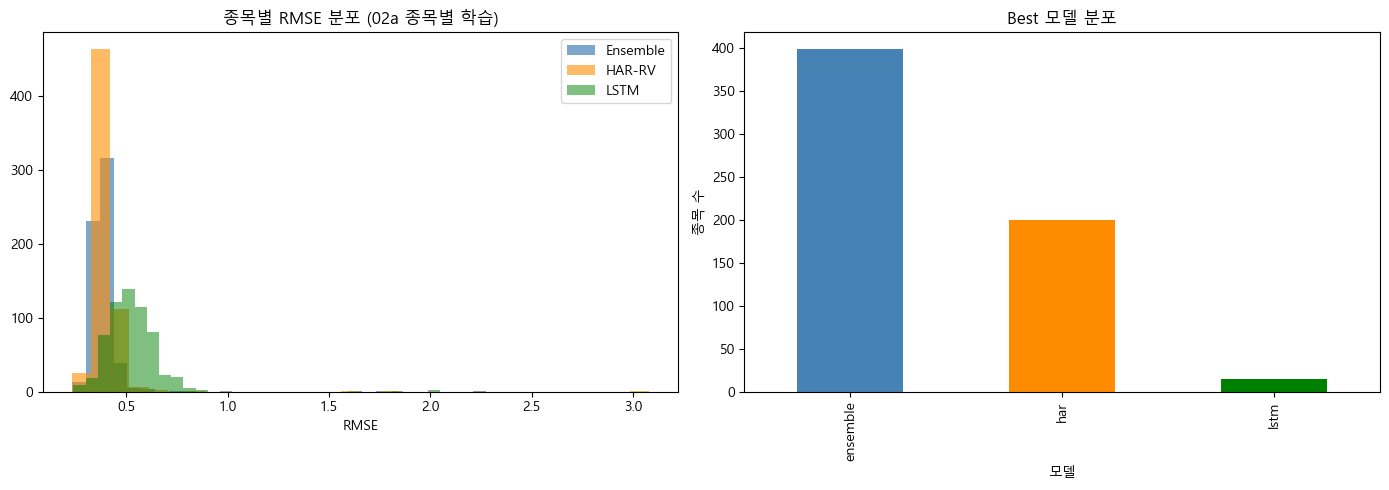

In [13]:
# 4-3. Best 모델 분포
best_model = rmse_by_ticker.apply(
    lambda row: 'lstm' if row['rmse_lstm'] == min(row['rmse_lstm'], row['rmse_har'], row['rmse_ensemble'])
               else ('har' if row['rmse_har'] == min(row['rmse_lstm'], row['rmse_har'], row['rmse_ensemble'])
                    else 'ensemble'),
    axis=1
)
print('=== Best 모델 분포 ===')
print(best_model.value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE 분포
axes[0].hist(rmse_by_ticker['rmse_ensemble'], bins=30, alpha=0.7, label='Ensemble', color='steelblue')
axes[0].hist(rmse_by_ticker['rmse_har'], bins=30, alpha=0.6, label='HAR-RV', color='darkorange')
axes[0].hist(rmse_by_ticker['rmse_lstm'], bins=30, alpha=0.5, label='LSTM', color='green')
axes[0].set_title('종목별 RMSE 분포 (02a 종목별 학습)', fontsize=12)
axes[0].set_xlabel('RMSE')
axes[0].legend()

# Best 모델 분포
best_model.value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'darkorange', 'green'])
axes[1].set_title('Best 모델 분포', fontsize=12)
axes[1].set_xlabel('모델')
axes[1].set_ylabel('종목 수')

plt.tight_layout()
plt.savefig(OUT_DIR / 'rmse_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## §5. Phase 1.5 v8 결과 비교

Phase 1.5 v8 (74 종목, 6 년 2020~2025) vs Phase 3 (확장 universe, 17 년 2009~2025).


In [14]:
from scripts.setup import PHASE2_DIR

phase2_ens_path = PHASE2_DIR / 'data' / 'ensemble_predictions_top50.csv'
if phase2_ens_path.exists():
    phase2_ens = pd.read_csv(phase2_ens_path, parse_dates=['date'])

    # Phase 2 와 공통 종목
    common_tickers = set(ensemble_sw['ticker'].unique()) & set(phase2_ens['ticker'].unique())
    print(f'공통 종목 수: {len(common_tickers)}')

    # Phase 2 vs Phase 3 RMSE 비교 (공통 종목 + 2021 이후 공통 기간)
    sw_sub = ensemble_sw[
        (ensemble_sw['ticker'].isin(common_tickers)) &
        (ensemble_sw['date'] >= '2021-01-01')
    ]
    p2_sub = phase2_ens[
        (phase2_ens['ticker'].isin(common_tickers)) &
        (phase2_ens['date'] >= '2021-01-01')
    ]

    sw_rmse = sw_sub.groupby('ticker').apply(
        lambda df: rmse(df['y_true'].values, df['y_pred_ensemble'].values)
    ).mean()
    p2_rmse = p2_sub.groupby('ticker').apply(
        lambda df: rmse(df['y_true'].values, df['y_pred_ensemble'].values)
    ).mean()

    print(f'Phase 2 Ensemble RMSE (2021+): {p2_rmse:.4f}')
    print(f'Phase 3 Stockwise RMSE (2021+): {sw_rmse:.4f}')
    print(f'차이 (Phase 3 - Phase 2): {sw_rmse - p2_rmse:+.4f}')
else:
    print(f'Phase 2 ensemble 파일 없음: {phase2_ens_path}')

공통 종목 수: 74
Phase 2 Ensemble RMSE (2021+): 0.3294
Phase 3 Stockwise RMSE (2021+): 0.3301
차이 (Phase 3 - Phase 2): +0.0007


C:\Users\gorhk\AppData\Local\Temp\ipykernel_27144\1003798313.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sw_rmse = sw_sub.groupby('ticker').apply(
C:\Users\gorhk\AppData\Local\Temp\ipykernel_27144\1003798313.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  p2_rmse = p2_sub.groupby('ticker').apply(


In [15]:
# 최종 요약
print('=== Phase 3 Step 2a 완료 ===')
print(f'산출물: {DATA_DIR / "ensemble_predictions_stockwise.csv"}')
print(f'종목 수: {ensemble_sw["ticker"].nunique()}')
print(f'기간: {ensemble_sw["date"].min().date()} ~ {ensemble_sw["date"].max().date()}')
print()
print('다음 단계:')
print('  02b_phase15_cross_sectional.ipynb   (Cross-Sectional 학습)')
print('  03_BL_backtest_extended.ipynb        (BL 백테스트 — 02a + 02b 완료 후)')

=== Phase 3 Step 2a 완료 ===
산출물: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data\ensemble_predictions_stockwise.csv
종목 수: 613
기간: 2007-04-23 ~ 2025-12-01

다음 단계:
  02b_phase15_cross_sectional.ipynb   (Cross-Sectional 학습)
  03_BL_backtest_extended.ipynb        (BL 백테스트 — 02a + 02b 완료 후)


## §6. 빠른 BL 백테스트 sanity check (02a 단독, 02b 학습 전)

> 02b cross-sectional 학습 완료 전에 **02a stockwise ensemble 만으로** BL 적용 가능성을 빠르게 검증.

**3 시나리오 비교**:
| 시나리오 | P 행렬 입력 |
|---|---|
| **BL_ml_sw** | 02a stockwise ensemble 예측 변동성 |
| **BL_trailing** | trailing vol_21d (서윤범 99 baseline 재현) |
| **SPY** | 시장 벤치마크 |

**모듈 활용** (`scripts.black_litterman`, `scripts.covariance`):
- `compute_pi(... lam_fixed=2.5)` — 서윤범 99 일관 LAM
- `build_P(... pct=0.30)` — 양극단 30% long/short
- `compute_omega`, `black_litterman(... tau=0.1)`, `optimize_portfolio`
- `estimate_covariance(daily_ret) → Σ_monthly` (LedoitWolf + ×21)

> 본 섹션은 **빠른 검증용 (BL_ml_sw 동작 여부 + 대략적 Sharpe)**. 정식 6 시나리오 백테스트는 03 노트북 참조.

In [16]:
# §6-1. 데이터 로드 + 사전 준비
from scripts.black_litterman import (
    compute_pi, build_P, compute_omega, black_litterman, optimize_portfolio,
    Q_FIXED, PCT_GROUP, DEFAULT_TAU, LAM_FIXED,
)
from scripts.covariance import estimate_covariance, DAYS_PER_MONTH

# panel + market
panel = pd.read_csv(
    DATA_DIR / 'daily_panel.csv', parse_dates=['date'],
    usecols=['date', 'ticker', 'log_ret', 'vol_21d', 'mcap_value', 'rf_daily'],
)
market = pd.read_csv(DATA_DIR / 'market_data.csv', index_col='date', parse_dates=True)
spy_daily = market['SPY'].pct_change().dropna()
spy_lr = np.log(1 + spy_daily)

# rf 일별
rf_daily = panel.groupby('date')['rf_daily'].mean()
rf_lr = rf_daily.reindex(spy_lr.index, method='ffill').fillna(0)

# 시장 risk premium (월별 환산)
spy_excess_monthly = float((spy_lr - rf_lr).mean() * DAYS_PER_MONTH)
spy_sigma2_monthly = float(spy_lr.var() * DAYS_PER_MONTH)
print(f'spy_excess_monthly: {spy_excess_monthly:.6f} (월 {spy_excess_monthly*100:.2f}%)')
print(f'spy_sigma2_monthly: {spy_sigma2_monthly:.6f}')

# 일별 ret pivot (Σ 추정용)
daily_lr = panel.pivot_table(index='date', columns='ticker', values='log_ret')
print(f'daily_lr: {daily_lr.shape}')

# 학습 종목 (02a)
trained_tickers = set(ensemble_sw['ticker'].unique())
print(f'학습 종목: {len(trained_tickers)}')

# Phase 3-2 (2026-04-30): OOS 2010-2024 + 2025 hold-out
OOS_START = '2010-01-01'
OOS_END = '2024-12-31'
HOLDOUT_START = '2025-01-01'
HOLDOUT_END = '2025-12-31'

reb_dates_all = market.groupby(market.index.to_period('M')).tail(1).index
oos_dates = reb_dates_all[(reb_dates_all >= OOS_START) & (reb_dates_all <= OOS_END)]
holdout_dates = reb_dates_all[(reb_dates_all >= HOLDOUT_START) & (reb_dates_all <= HOLDOUT_END)]
reb_dates = pd.DatetimeIndex(list(oos_dates) + list(holdout_dates))
month_to_eom = {pd.Timestamp(d).to_period('M'): pd.Timestamp(d) for d in reb_dates}
print(f'리밸런싱 시점 (Phase 3-2):')
print(f'  OOS      ({OOS_START}~{OOS_END}): {len(oos_dates)} 개월')
print(f'  Hold-out ({HOLDOUT_START}~{HOLDOUT_END}): {len(holdout_dates)} 개월')
print(f'  total: {len(reb_dates)} 개월')

# ML 예측 월별 피벗 (rebalance date 기준)
ens_copy = ensemble_sw.copy()
ens_copy['month'] = ens_copy['date'].dt.to_period('M')
ml_monthly = ens_copy.groupby(['ticker', 'month'])['y_pred_ensemble'].last().reset_index()
ml_monthly['rebalance_date'] = ml_monthly['month'].map(month_to_eom)
ml_monthly = ml_monthly.dropna(subset=['rebalance_date'])
ml_pred_pivot = ml_monthly.pivot_table(
    index='rebalance_date', columns='ticker', values='y_pred_ensemble'
)
print(f'ml_pred_pivot: {ml_pred_pivot.shape}')

# ⭐ 시점별 S&P 500 멤버십 (Dynamic-Membership, 2026-04-30)
# Static (panel ∩ trained) → Dynamic (member_at_t ∩ panel ∩ trained) 전환
from scripts.universe import get_or_build_membership
membership = get_or_build_membership(
    start=pd.Timestamp('2008-12-01'),
    end=pd.Timestamp('2026-01-01'),
    cache_path=DATA_DIR / 'sp500_membership.pkl',
)
print(f'membership (Dynamic-Membership): {len(membership)} 월말 시점')

# Phase 3-2 v2 경로
OUT_DIR_V2_SW = OUTPUTS_DIR / '02a_v2_stockwise'
OUT_DIR_V2_SW.mkdir(parents=True, exist_ok=True)
CACHE_PATH_V2 = DATA_DIR / 'bl_weights_v2_sanity_check.pkl'
METRICS_PKL_V2 = DATA_DIR / 'bl_metrics_v2_sanity_check.pkl'
print(f'\nv2 산출 폴더: {OUT_DIR_V2_SW.name}')
print(f'v2 BL 캐시:   {CACHE_PATH_V2.name}')
print(f'v2 메트릭:    {METRICS_PKL_V2.name}')

spy_excess_monthly: 0.006391 (월 0.64%)
spy_sigma2_monthly: 0.003031


daily_lr: (6038, 646)
학습 종목: 613
리밸런싱 시점 (Phase 3-2):
  OOS      (2010-01-01~2024-12-31): 180 개월
  Hold-out (2025-01-01~2025-12-31): 12 개월
  total: 192 개월


ml_pred_pivot: (192, 613)


membership (Dynamic-Membership): 204 월말 시점

v2 산출 폴더: 02a_v2_stockwise
v2 BL 캐시:   bl_weights_v2_sanity_check.pkl
v2 메트릭:    bl_metrics_v2_sanity_check.pkl


In [17]:
# §6-2. BL 백테스트 walk-forward 루프 (2 시나리오: BL_ml_sw, BL_trailing)
# ⭐ 캐시 추가 (2026-04-30): 200+ 시점 walk-forward 비싸므로 결과 pickle 캐시
import warnings
warnings.filterwarnings('ignore')
import pickle

DAYS_IS = 1260            # IS 5년 (서윤범 일관)
MIN_UNIVERSE = 30          # 매월 최소 종목 (서윤범 일관)
MIN_VALID_TIX = 20         # 60% threshold 후 최소 종목
STALE_RATIO_THRESHOLD = 0.30   # ⭐ stale price 필터 threshold (Step 8, 2026-04-30)

# 캐시 경로 + 강제 재계산 플래그
CACHE_PATH = CACHE_PATH_V2  # Phase 3-2 v2 cache
FORCE_RECOMPUTE = False    # ⭐ True 시 캐시 무시 + 재계산 (디버깅·재실험 시)

if CACHE_PATH.exists() and not FORCE_RECOMPUTE:
    with open(CACHE_PATH, 'rb') as f:
        cache = pickle.load(f)
    weights = cache['weights']
    n_skip = cache['n_skip']
    n_sigma_fail = cache['n_sigma_fail']
    print(f'⚡ 캐시 사용: {CACHE_PATH.name} (재계산 생략)')
    print(f'  강제 재계산: FORCE_RECOMPUTE = True 변경 후 재실행')
    print(f'  결과 (캐시):')
    for s_name, w_dict in weights.items():
        print(f'  BL_{s_name} 가중치: {len(w_dict)} 시점')
    print(f'  Skip (universe 부족): {n_skip}')
    print(f'  Σ 추정 실패: {n_sigma_fail}')
else:
    if FORCE_RECOMPUTE:
        print('⚠️ FORCE_RECOMPUTE=True → 캐시 무시 + 재계산')

    # Phase 3-2: 6 시나리오 (BL_ml_sw 3 + BL_trailing 3)
    WEIGHTINGS = ['mcap', 'eq', 'rp']
    weights = {f'ml_sw_{w}': {} for w in WEIGHTINGS}
    weights.update({f'trailing_{w}': {} for w in WEIGHTINGS})
    n_skip = 0
    n_sigma_fail = 0

    try:
        from tqdm.auto import tqdm
        iterator = tqdm(reb_dates, desc='BL backtest', ncols=100)
    except ImportError:
        iterator = reb_dates

    for reb_date in iterator:
        # universe = sp500_member_at_t ∩ panel 가용 ∩ 학습 615 ∩ non-stale
        # (Dynamic-Membership Step 7 + Stale 필터 Step 8, 2026-04-30)
        panel_at = panel[panel['date'] == reb_date].dropna(
            subset=['vol_21d', 'mcap_value', 'log_ret']
        )
        # ⭐ reb_date (거래일 월말) → 동일 month 의 calendar 월말 키로 멤버십 lookup
        month_end_key = pd.Timestamp(reb_date.to_period('M').to_timestamp(how='end').normalize())
        members_at_date = membership.get(month_end_key, frozenset())
        # ⭐ stale price 필터 (Step 8): IS 1260일 안에서 zero ratio > 30% 종목 제외
        #   대상: SW (65.8%), CPWR (67.5%), COL (59.9%), EP (53.3%) 등 ticker 재사용·인수 후 stale
        is_window = daily_lr.loc[reb_date - pd.offsets.BDay(1260):reb_date]
        zero_ratio = (is_window == 0).mean()
        non_stale = set(zero_ratio[zero_ratio <= STALE_RATIO_THRESHOLD].index)
        avail = members_at_date & set(panel_at['ticker']) & trained_tickers & non_stale
        if len(avail) < MIN_UNIVERSE:
            n_skip += 1
            continue

        # IS 데이터
        is_end = reb_date
        is_start = is_end - pd.offsets.BDay(DAYS_IS)
        is_data = daily_lr.loc[is_start:is_end, :]
        cols_in_data = [t for t in avail if t in is_data.columns]
        valid_tix = [t for t in cols_in_data
                      if is_data[t].notna().sum() >= int(DAYS_IS * 0.7)]
        if len(valid_tix) < MIN_VALID_TIX:
            n_skip += 1
            continue

        # ⭐ Issue 4 fix (2026-04-30 재적용)
        # estimate_covariance 는 (returns, is_start, is_end) 3개 인자 필수.
        # dropna() 는 너무 공격적 (한 종목 결측 → 행 전체 제거) → fillna(0) (서윤범 99 일관).
        try:
            Sigma = estimate_covariance(
                is_data[valid_tix].fillna(0),
                is_start=is_start,
                is_end=is_end,
            )
        except Exception as e:
            if n_sigma_fail < 3:
                print(f'  [{reb_date.date()}] Sigma 실패: {type(e).__name__}: {str(e)[:80]}')
            n_sigma_fail += 1
            continue

        # 공통 종목 (Σ ∩ panel mcap)
        panel_idx = panel_at.set_index('ticker')
        mcap = panel_idx['mcap_value'].reindex(Sigma.index).dropna()
        common = list(mcap.index)
        if len(common) < MIN_VALID_TIX:
            n_skip += 1
            continue

        Sigma_c = Sigma.loc[common, common]
        mcap_c = mcap[common]
        w_mkt = mcap_c / mcap_c.sum()

        # CAPM 역산 (서윤범 99: lam_fixed=2.5)
        pi, lam = compute_pi(Sigma_c, w_mkt, spy_excess_monthly, spy_sigma2_monthly,
                              lam_fixed=LAM_FIXED)

        # 시나리오 1: BL_ml_sw - 3 weighting (mcap/eq/rp)
        if reb_date in ml_pred_pivot.index:
            vol_ml = ml_pred_pivot.loc[reb_date].reindex(common).dropna()
            vol_ml_actual = np.exp(vol_ml)
            if len(vol_ml_actual) >= 5:
                for w_method in WEIGHTINGS:
                    P_ml = build_P(vol_ml_actual, mcap_c[vol_ml_actual.index],
                                    pct=PCT_GROUP, weighting=w_method)
                    P_ml = P_ml.reindex(common).fillna(0)
                    omega_ml = compute_omega(P_ml, Sigma_c, DEFAULT_TAU)
                    mu_ml = black_litterman(pi, Sigma_c, P_ml, q=Q_FIXED,
                                             omega=omega_ml, tau=DEFAULT_TAU)
                    w_ml = optimize_portfolio(mu_ml, Sigma_c, lam)
                    weights[f'ml_sw_{w_method}'][reb_date] = w_ml

        # 시나리오 2: BL_trailing - 3 weighting (mcap/eq/rp)
        vol_t = panel_idx['vol_21d'].reindex(common).dropna()
        if len(vol_t) >= 5:
            for w_method in WEIGHTINGS:
                P_t = build_P(vol_t, mcap_c[vol_t.index],
                               pct=PCT_GROUP, weighting=w_method)
                P_t = P_t.reindex(common).fillna(0)
                omega_t = compute_omega(P_t, Sigma_c, DEFAULT_TAU)
                mu_t = black_litterman(pi, Sigma_c, P_t, q=Q_FIXED,
                                        omega=omega_t, tau=DEFAULT_TAU)
                w_t = optimize_portfolio(mu_t, Sigma_c, lam)
                weights[f'trailing_{w_method}'][reb_date] = w_t

    # 캐시 저장 (Phase 3-2 v2)
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump({
            'weights': weights,
            'n_skip': n_skip,
            'n_sigma_fail': n_sigma_fail,
        }, f)

    print(f'  결과 (Phase 3-2 v2):')
    for s_name, w_dict in weights.items():
        print(f'  BL_{s_name} 가중치: {len(w_dict)} 시점')
    print(f'  Skip (universe 부족): {n_skip}')
    print(f'  Σ 추정 실패: {n_sigma_fail}')
    print(f'  💾 캐시 저장: {CACHE_PATH.name}')

⚡ 캐시 사용: bl_weights_v2_sanity_check.pkl (재계산 생략)
  강제 재계산: FORCE_RECOMPUTE = True 변경 후 재실행
  결과 (캐시):
  BL_ml_sw_mcap 가중치: 192 시점
  BL_ml_sw_eq 가중치: 192 시점
  BL_ml_sw_rp 가중치: 192 시점
  BL_trailing_mcap 가중치: 192 시점
  BL_trailing_eq 가중치: 192 시점
  BL_trailing_rp 가중치: 192 시점
  Skip (universe 부족): 0
  Σ 추정 실패: 0


In [18]:
# §6-3. 월별 returns 계산 + 포트폴리오 returns
# ⭐ Issue 5 fix (2026-04-30 재적용): backtest_strategy 가 빈 Series 반환 → make_returns_manual 우회

# 종목별 월별 수익률 (market eom 기준)
def compute_monthly_returns_sw(panel_df, tickers, month_to_eom):
    """일별 log_ret 합 → 월별 단순 수익률, market eom 인덱스."""
    sub = panel_df[panel_df['ticker'].isin(tickers)].set_index('date')
    sub['month'] = sub.index.to_period('M')
    monthly_lr = sub.groupby(['ticker', 'month'])['log_ret'].sum().reset_index()
    monthly_lr['date'] = monthly_lr['month'].map(month_to_eom)
    monthly_lr = monthly_lr.dropna(subset=['date'])
    monthly_lr['ret'] = np.exp(monthly_lr['log_ret']) - 1
    return monthly_lr.pivot_table(index='date', columns='ticker', values='ret')

all_tickers = sorted(trained_tickers)
monthly_rets = compute_monthly_returns_sw(panel, all_tickers, month_to_eom)
print(f'monthly_rets: {monthly_rets.shape}')

# forward (현재 가중치 → 다음 달 수익률)
forward_rets = monthly_rets.shift(-1)


def make_returns_manual(weights_dict, name, forward_rets):
    """직접 계산 (backtest_strategy 우회).
    weights_dict[date] = pd.Series(ticker → weight)
    """
    if not weights_dict:
        return pd.Series(dtype=float, name=name)

    rets = []
    dates = []
    for reb_date in sorted(weights_dict.keys()):
        w = weights_dict[reb_date]
        if reb_date not in forward_rets.index:
            continue
        # 다음 달 수익률 (forward)
        r_next = forward_rets.loc[reb_date]
        # 공통 ticker 만 사용
        common_t = w.index.intersection(r_next.index)
        if len(common_t) == 0:
            continue
        w_c = w.reindex(common_t).fillna(0)
        r_c = r_next.reindex(common_t).fillna(0)
        # 가중 수익률 합
        port_ret = float((w_c * r_c).sum())
        rets.append(port_ret)
        dates.append(reb_date)

    if not rets:
        return pd.Series(dtype=float, name=name)
    return pd.Series(rets, index=pd.DatetimeIndex(dates), name=name)


# Phase 3-2 v2: 6 시나리오 returns
returns_v2 = {}
for s_name, w_dict in weights.items():
    returns_v2[f'BL_{s_name}'] = make_returns_manual(w_dict, f'BL_{s_name}', forward_rets)

ret_ml = returns_v2['BL_ml_sw_mcap']
ret_tr = returns_v2['BL_trailing_mcap']

# SPY 월별 수익률 (rebalance date 기준)
spy_monthly = (1 + spy_daily).resample('ME').prod() - 1
spy_monthly_at_eom = spy_monthly.reindex(reb_dates, method='nearest')
ret_spy = spy_monthly_at_eom.shift(-1).dropna().rename('SPY')

print()
print('=== Phase 3-2 v2 returns (6 BL) ===')
for s_name, ret in returns_v2.items():
    print(f'  {s_name:25s}: {len(ret)} 개월')
print(f'  SPY                       : {len(ret_spy)} 개월')

monthly_rets: (192, 613)



=== Phase 3-2 v2 returns (6 BL) ===
  BL_ml_sw_mcap            : 192 개월
  BL_ml_sw_eq              : 192 개월
  BL_ml_sw_rp              : 192 개월
  BL_trailing_mcap         : 192 개월
  BL_trailing_eq           : 192 개월
  BL_trailing_rp           : 192 개월
  SPY                       : 191 개월


In [19]:
# §6-4. 메트릭 계산 (Sharpe / CAGR / MDD) + Fair 비교
def compute_metrics(rets, annual_factor=12):
    if len(rets) == 0:
        return {k: np.nan for k in ['sharpe', 'cagr', 'ann_vol', 'mdd', 'n']}
    ann_ret = rets.mean() * annual_factor
    ann_vol = rets.std() * np.sqrt(annual_factor)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum = (1 + rets).cumprod()
    mdd = (cum / cum.cummax() - 1).min()
    n = len(rets)
    cagr = cum.iloc[-1] ** (annual_factor / n) - 1 if n > 0 else np.nan
    return {
        'sharpe': sharpe,
        'cagr_%': cagr * 100,
        'ann_vol_%': ann_vol * 100,
        'mdd_%': mdd * 100,
        'n_months': n,
    }

# Phase 3-2 v2: 6 BL + SPY fair 비교
common_idx = ret_ml.index.intersection(ret_tr.index).intersection(ret_spy.index)
ret_ml_fair = ret_ml.reindex(common_idx).dropna()
ret_tr_fair = ret_tr.reindex(common_idx).dropna()
ret_spy_fair = ret_spy.reindex(common_idx).dropna()

print(f'공통 기간: {common_idx[0].date()} ~ {common_idx[-1].date()} ({len(common_idx)} 개월)')
print()

# 모든 시나리오 fair 정렬
all_returns = dict(returns_v2)  # returns_v2 키 이미 BL_ prefix 포함 (이중 prefix 방지)
all_returns['SPY'] = ret_spy
all_returns_fair = {n: r.reindex(common_idx).dropna() for n, r in all_returns.items()}

metrics_table = pd.DataFrame({
    name: compute_metrics(r) for name, r in all_returns_fair.items()
}).T.round(3)

print('=== 3 시나리오 Fair 비교 ===')
print(metrics_table.to_string())

# ML vs Trailing 차이 (mcap default)
delta_sharpe = metrics_table.loc['BL_ml_sw_mcap', 'sharpe'] - metrics_table.loc['BL_trailing_mcap', 'sharpe']
delta_cagr = metrics_table.loc['BL_ml_sw_mcap', 'cagr_%'] - metrics_table.loc['BL_trailing_mcap', 'cagr_%']
delta_mdd = metrics_table.loc['BL_ml_sw_mcap', 'mdd_%'] - metrics_table.loc['BL_trailing_mcap', 'mdd_%']

print()
print('=== ML 통합 효과 (BL_ml_sw - BL_trailing) ===')
print(f'  Sharpe 차이: {delta_sharpe:+.3f}')
print(f'  CAGR 차이:   {delta_cagr:+.2f}%')
print(f'  MDD 차이:    {delta_mdd:+.2f}%  (음수 = ML 이 손실 더 큼)')

# 서윤범 99 비교 (참고)
print()
print('=== 서윤범 99 baseline 참고 ===')
print('  보고 Sharpe: 1.065 (재계산 1.157)')
print(f'  Phase 3 BL_trailing Sharpe (현재): {metrics_table.loc["BL_trailing_mcap", "sharpe"]:.3f}')
print(f'  차이: {(metrics_table.loc["BL_trailing_mcap", "sharpe"] - 1.157) / 1.157 * 100:+.2f}% from 서윤범 (재계산)')

# ⭐ metrics 저장 (05a §7-5/§7-8 결론 텍스트 변수 참조용, 2026-04-30)
import pickle
metrics_pkl_path = DATA_DIR / 'bl_metrics_sanity_check.pkl'
with open(metrics_pkl_path, 'wb') as f:
    pickle.dump({
        'metrics_table': metrics_table.to_dict(),
        'delta_sharpe': delta_sharpe,
        'delta_cagr': delta_cagr,
        'delta_mdd': delta_mdd,
    }, f)
print(f'\n💾 metrics 저장: {metrics_pkl_path.name} (05a §7-5/§7-8 변수 참조용)')

# Phase 3-2 v2: OOS / Hold-out 분리 메트릭
print()
print('=' * 75)
print('  Phase 3-2: OOS (2010-2024) / Hold-out (2025) 분리')
print('=' * 75)

oos_returns = {n: r.loc[OOS_START:OOS_END] for n, r in all_returns_fair.items()}
holdout_returns = {n: r.loc[HOLDOUT_START:HOLDOUT_END] for n, r in all_returns_fair.items()}

metrics_oos = pd.DataFrame({n: compute_metrics(r) for n, r in oos_returns.items()}).T.round(3)
metrics_holdout = pd.DataFrame({n: compute_metrics(r) for n, r in holdout_returns.items()}).T.round(3)

print(f'\n=== OOS 메트릭 ({OOS_START} ~ {OOS_END}) ===')
print(metrics_oos.to_string())

print(f'\n=== Hold-out 메트릭 ({HOLDOUT_START} ~ {HOLDOUT_END}) ===')
print(metrics_holdout.to_string())

print(f'\n=== 가중치 robustness (OOS, BL_ml_sw vs BL_trailing) ===')
robustness = pd.DataFrame({
    'ml_sw_mcap':    metrics_oos.loc['BL_ml_sw_mcap'],
    'ml_sw_eq':      metrics_oos.loc['BL_ml_sw_eq'],
    'ml_sw_rp':      metrics_oos.loc['BL_ml_sw_rp'],
    'trailing_mcap': metrics_oos.loc['BL_trailing_mcap'],
    'trailing_eq':   metrics_oos.loc['BL_trailing_eq'],
    'trailing_rp':   metrics_oos.loc['BL_trailing_rp'],
}).round(3)
print(robustness.to_string())

# metrics 저장 (05a_v2 §7-5/§7-8 변수 참조용)
import pickle
with open(METRICS_PKL_V2, 'wb') as f:
    pickle.dump({
        'metrics_table': metrics_table.to_dict(),
        'metrics_oos': metrics_oos.to_dict(),
        'metrics_holdout': metrics_holdout.to_dict(),
        'delta_sharpe': delta_sharpe,
        'delta_cagr': delta_cagr,
        'delta_mdd': delta_mdd,
    }, f)
print(f'\n저장: {METRICS_PKL_V2.name}')


# ============================================================================
# Phase 3-2 v2: 추가 심층 분석 (α/β/γ)
# ============================================================================

# α. 가중치별 시기별 분해 (5 시기 x 6 시나리오)
PERIODS_V2 = {
    'GFC 회복 (10~11)':  ('2010-01-01', '2011-12-31'),
    '강세장 (12~19)':     ('2012-01-01', '2019-12-31'),
    'COVID (20)':       ('2020-01-01', '2020-12-31'),
    '긴축 (21~22)':      ('2021-01-01', '2022-12-31'),
    '회복·AI (23~24)':   ('2023-01-01', '2024-12-31'),
}

period_results = {}
for period_name, (s, e) in PERIODS_V2.items():
    period_returns = {n: r.loc[s:e] for n, r in all_returns_fair.items()}
    period_results[period_name] = pd.DataFrame({
        n: compute_metrics(r) for n, r in period_returns.items()
    }).T.round(3)

print()
print('=' * 75)
print('  α. 가중치별 시기별 Sharpe (BL_ml_sw vs BL_trailing diff)')
print('=' * 75)
robust_period = pd.DataFrame(index=list(PERIODS_V2.keys()), columns=['mcap', 'eq', 'rp'])
for period_name in PERIODS_V2:
    pm = period_results[period_name]
    for w_method in ['mcap', 'eq', 'rp']:
        if f'BL_ml_sw_{w_method}' in pm.index and f'BL_trailing_{w_method}' in pm.index:
            diff = pm.loc[f'BL_ml_sw_{w_method}', 'sharpe'] - pm.loc[f'BL_trailing_{w_method}', 'sharpe']
            robust_period.loc[period_name, w_method] = round(diff, 3)
print(robust_period.to_string())

# 시기별 BL_ml_sw 6 시나리오 + BL_trailing 의 Sharpe 매트릭스
print()
for period_name, pm in period_results.items():
    print(f'\n--- {period_name} ---')
    bl_rows = [r for r in pm.index if r.startswith('BL_')]
    print(pm.loc[bl_rows, ['sharpe', 'cagr_%', 'mdd_%']].to_string())


# β. Turnover 분석
def compute_turnover_series(weights_dict):
    """매월 turnover = 0.5 * sum(|w_t - w_{t-1}|)"""
    dates = sorted(weights_dict.keys())
    if len(dates) < 2:
        return pd.Series(dtype=float)
    turnovers = []
    for i in range(1, len(dates)):
        w_prev = weights_dict[dates[i-1]]
        w_curr = weights_dict[dates[i]]
        all_t = w_prev.index.union(w_curr.index)
        d = (w_curr.reindex(all_t).fillna(0) - w_prev.reindex(all_t).fillna(0)).abs().sum() / 2
        turnovers.append(d)
    return pd.Series(turnovers, index=dates[1:])

print()
print('=' * 75)
print('  β. 6 시나리오 평균 monthly turnover')
print('=' * 75)
turnover_summary = {}
for s_name, w_dict in weights.items():
    tov = compute_turnover_series(w_dict)
    turnover_summary[f'BL_{s_name}'] = {
        'mean': tov.mean(),
        'std': tov.std(),
        'max': tov.max(),
        'min': tov.min(),
    }
turnover_table = pd.DataFrame(turnover_summary).T.round(3)
print(turnover_table.to_string())


# γ. 가중치 분포 (종목 수, top10 concentration, 평균 mcap)
print()
print('=' * 75)
print('  γ. 6 시나리오 가중치 분포')
print('=' * 75)
dist_summary = {}
for s_name, w_dict in weights.items():
    n_stocks_list = [len(w) for w in w_dict.values()]
    top10_concs = []
    top1_concs = []
    for w in w_dict.values():
        if len(w) >= 10:
            top10_concs.append(abs(w).nlargest(10).sum())
        if len(w) >= 1:
            top1_concs.append(abs(w).max())
    dist_summary[f'BL_{s_name}'] = {
        'avg_n': round(sum(n_stocks_list) / len(n_stocks_list), 1),
        'top10_%': round(sum(top10_concs) / len(top10_concs) * 100, 2) if top10_concs else None,
        'top1_%': round(sum(top1_concs) / len(top1_concs) * 100, 2) if top1_concs else None,
    }
dist_table = pd.DataFrame(dist_summary).T
print(dist_table.to_string())

# turnover + dist 도 metrics pkl 에 추가 저장
import pickle
with open(METRICS_PKL_V2, 'wb') as f:
    pickle.dump({
        'metrics_table': metrics_table.to_dict(),
        'metrics_oos': metrics_oos.to_dict(),
        'metrics_holdout': metrics_holdout.to_dict(),
        'period_results': {k: v.to_dict() for k, v in period_results.items()},
        'robust_period': robust_period.to_dict(),
        'turnover_summary': turnover_summary,
        'dist_summary': dist_summary,
        'delta_sharpe': delta_sharpe,
        'delta_cagr': delta_cagr,
        'delta_mdd': delta_mdd,
    }, f)
print(f'\nmetrics_v2 갱신: {METRICS_PKL_V2.name} (period + turnover + dist 추가)')

공통 기간: 2010-01-29 ~ 2025-11-28 (191 개월)

=== 3 시나리오 Fair 비교 ===
                   sharpe    cagr_%  ann_vol_%      mdd_%   n_months
BL_ml_sw_mcap    1.092000 12.700000  11.619000 -18.128000 191.000000
BL_ml_sw_eq      1.139000 12.724000  11.112000 -16.577000 191.000000
BL_ml_sw_rp      1.125000 12.558000  11.118000 -16.497000 191.000000
BL_trailing_mcap 1.188000 13.872000  11.546000 -16.483000 191.000000
BL_trailing_eq   1.150000 12.595000  10.878000 -15.938000 191.000000
BL_trailing_rp   1.147000 12.570000  10.891000 -15.981000 191.000000
SPY              1.013000 14.360000  14.325000 -23.927000 191.000000

=== ML 통합 효과 (BL_ml_sw - BL_trailing) ===
  Sharpe 차이: -0.096
  CAGR 차이:   -1.17%
  MDD 차이:    -1.64%  (음수 = ML 이 손실 더 큼)

=== 서윤범 99 baseline 참고 ===
  보고 Sharpe: 1.065 (재계산 1.157)
  Phase 3 BL_trailing Sharpe (현재): 1.188
  차이: +2.68% from 서윤범 (재계산)

💾 metrics 저장: bl_metrics_sanity_check.pkl (05a §7-5/§7-8 변수 참조용)

  Phase 3-2: OOS (2010-2024) / Hold-out (2025) 분리

=== OOS 메트릭 (20

                     mean      std      max      min
BL_ml_sw_mcap    0.216000 0.091000 0.759000 0.043000
BL_ml_sw_eq      0.131000 0.063000 0.725000 0.051000
BL_ml_sw_rp      0.132000 0.067000 0.765000 0.051000
BL_trailing_mcap 0.381000 0.134000 0.769000 0.108000
BL_trailing_eq   0.280000 0.109000 0.638000 0.080000
BL_trailing_rp   0.291000 0.117000 0.677000 0.088000

  γ. 6 시나리오 가중치 분포


                      avg_n   top10_%   top1_%
BL_ml_sw_mcap    423.300000 35.730000 5.920000
BL_ml_sw_eq      423.300000 31.950000 4.690000
BL_ml_sw_rp      423.300000 32.650000 4.770000
BL_trailing_mcap 423.300000 42.000000 8.470000
BL_trailing_eq   423.300000 35.720000 5.360000
BL_trailing_rp   423.300000 36.500000 5.500000

metrics_v2 갱신: bl_metrics_v2_sanity_check.pkl (period + turnover + dist 추가)


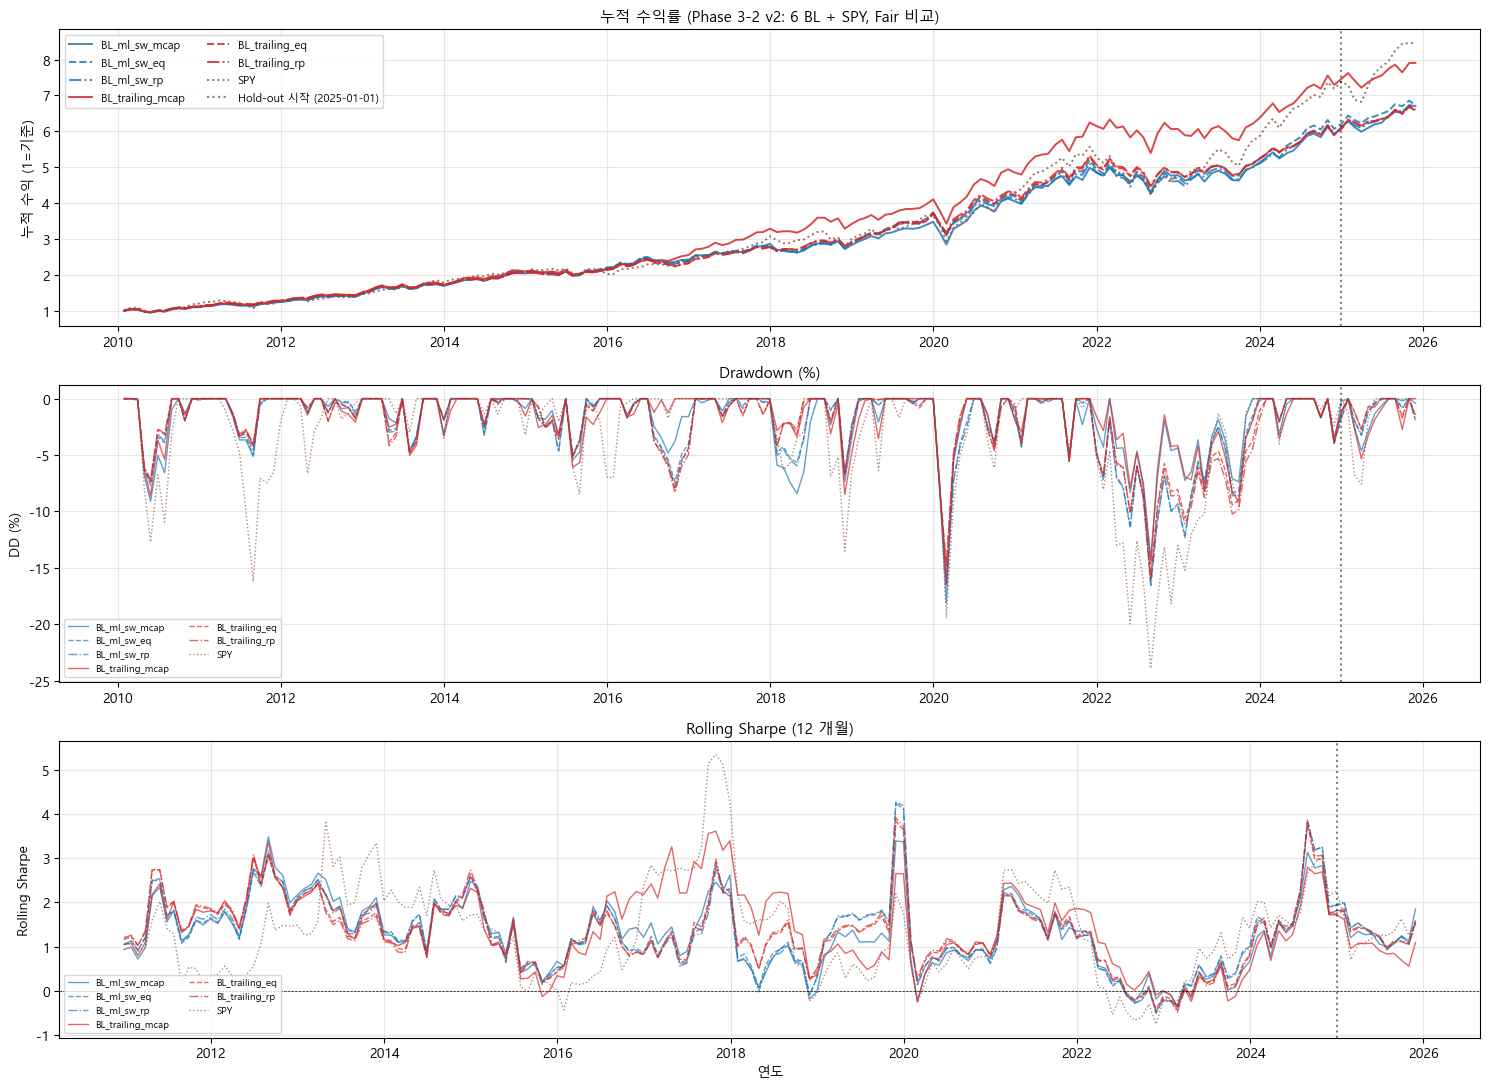


시각화 저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\outputs\02a_v2_stockwise\bl_sanity_check.png

판정 기준:
  - BL_trailing_mcap Sharpe ≈ 1.0~1.2 → 서윤범 99 재현 OK
  - 가중치 robustness: mcap/eq/rp 환경에서 BL_ml_sw vs BL_trailing diff 일관성
  - Hold-out (2025) 시기 BL_ml_sw vs BL_trailing 비교

💡 정식 9 시나리오 (+EW, +Mcap, +BL_ml_cs) 평가는 02b 완료 후 03_v2 노트북.


In [20]:
# §6-5. 시각화 (누적 수익률 + Drawdown + Rolling Sharpe) — Phase 3-2 v2: 6 BL + SPY
fig, axes = plt.subplots(3, 1, figsize=(15, 11))

# 색깔 / 스타일 — mcap 실선, eq 점선, rp 대시-닷
COLORS_V2 = {
    'BL_ml_sw_mcap':    ('#1f77b4', '-'),
    'BL_ml_sw_eq':      ('#1f77b4', '--'),
    'BL_ml_sw_rp':      ('#1f77b4', '-.'),
    'BL_trailing_mcap': ('#d62728', '-'),
    'BL_trailing_eq':   ('#d62728', '--'),
    'BL_trailing_rp':   ('#d62728', '-.'),
    'SPY':              ('#8c564b', ':'),
}

# Panel 1: 누적 수익률 (Fair 비교)
ax = axes[0]
for name, ret in all_returns_fair.items():
    color, ls = COLORS_V2.get(name, ('gray', '-'))
    cum = (1 + ret).cumprod()
    ax.plot(cum.index, cum.values, label=name, color=color, linestyle=ls,
            linewidth=1.4, alpha=0.85)
ax.set_title('누적 수익률 (Phase 3-2 v2: 6 BL + SPY, Fair 비교)', fontsize=11)
ax.set_ylabel('누적 수익 (1=기준)')
ax.axvline(pd.Timestamp(HOLDOUT_START), color='black', linestyle=':', alpha=0.5,
            label=f'Hold-out 시작 ({HOLDOUT_START})')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(alpha=0.3)

# Panel 2: Drawdown
ax = axes[1]
for name, ret in all_returns_fair.items():
    color, ls = COLORS_V2.get(name, ('gray', '-'))
    cum = (1 + ret).cumprod()
    dd = (cum / cum.cummax() - 1) * 100
    ax.plot(dd.index, dd.values, label=name, color=color, linestyle=ls,
            linewidth=1.0, alpha=0.7)
ax.set_title('Drawdown (%)', fontsize=11)
ax.set_ylabel('DD (%)')
ax.axvline(pd.Timestamp(HOLDOUT_START), color='black', linestyle=':', alpha=0.5)
ax.legend(loc='lower left', fontsize=7, ncol=2)
ax.grid(alpha=0.3)

# Panel 3: Rolling Sharpe (12 개월)
ax = axes[2]
for name, ret in all_returns_fair.items():
    color, ls = COLORS_V2.get(name, ('gray', '-'))
    rolling_sharpe = ret.rolling(12).apply(lambda x: x.mean() / x.std() * np.sqrt(12) if x.std() > 0 else np.nan)
    ax.plot(rolling_sharpe.index, rolling_sharpe.values, label=name,
            color=color, linestyle=ls, linewidth=1.0, alpha=0.7)
ax.set_title('Rolling Sharpe (12 개월)', fontsize=11)
ax.set_xlabel('연도')
ax.set_ylabel('Rolling Sharpe')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.axvline(pd.Timestamp(HOLDOUT_START), color='black', linestyle=':', alpha=0.5)
ax.legend(loc='lower left', fontsize=7, ncol=2)
ax.grid(alpha=0.3)

plt.tight_layout()
out_path = OUT_DIR_V2_SW / 'bl_sanity_check.png'
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'\n시각화 저장: {out_path}')

print()
print('판정 기준:')
print('  - BL_trailing_mcap Sharpe ≈ 1.0~1.2 → 서윤범 99 재현 OK')
print('  - 가중치 robustness: mcap/eq/rp 환경에서 BL_ml_sw vs BL_trailing diff 일관성')
print('  - Hold-out (2025) 시기 BL_ml_sw vs BL_trailing 비교')
print()
print('💡 정식 9 시나리오 (+EW, +Mcap, +BL_ml_cs) 평가는 02b 완료 후 03_v2 노트북.')

In [21]:
# §6-6. Hit rate 분석 — ML vs Trailing 의 양극단 30% 식별 정확도
# (BL_ml_sw 가 BL_trailing 보다 약한 이유 진단)

print('=' * 70)
print('  Hit Rate 분석: ML 예측 vs Trailing 이 실제 양극단 30% 를 잘 식별하는가?')
print('=' * 70)

# ─── 1. Pivot 데이터 준비 (3 종) ───
# (a) ML 예측: ml_pred_pivot 이미 §6-1 에서 생성됨 (reb_dates × tickers)

# (b) 실제 vol (y_true): ensemble_sw 의 y_true 를 같은 형식으로
ens_truth = ensemble_sw.copy()
ens_truth['month'] = ens_truth['date'].dt.to_period('M')
truth_monthly = ens_truth.groupby(['ticker', 'month'])['y_true'].last().reset_index()
truth_monthly['rebalance_date'] = truth_monthly['month'].map(month_to_eom)
truth_monthly = truth_monthly.dropna(subset=['rebalance_date'])
actual_pivot = truth_monthly.pivot_table(
    index='rebalance_date', columns='ticker', values='y_true'
)

# (c) Trailing vol_21d (panel 의 reb_date 시점 값)
trailing_pivot = panel.pivot_table(index='date', columns='ticker', values='vol_21d')
trailing_pivot = trailing_pivot.reindex(reb_dates)

print(f'ml_pred_pivot:  {ml_pred_pivot.shape}')
print(f'actual_pivot:   {actual_pivot.shape}')
print(f'trailing_pivot: {trailing_pivot.shape}')


# ─── 2. Hit rate 계산 함수 ───
from scipy.stats import spearmanr

def compute_hit_rates(predictor_pivot, actual_pivot, reb_dates, pct=0.30, min_n=30):
    """매 reb_date 의 양극단 30% 일치율 + Spearman 반환."""
    rows = []
    for reb_date in reb_dates:
        if reb_date not in predictor_pivot.index or reb_date not in actual_pivot.index:
            continue
        pred = predictor_pivot.loc[reb_date].dropna()
        actual = actual_pivot.loc[reb_date].dropna()
        common = pred.index.intersection(actual.index)
        if len(common) < min_n:
            continue
        pred_c = pred.loc[common]
        actual_c = actual.loc[common]
        n_group = max(1, int(len(common) * pct))

        pred_low = set(pred_c.nsmallest(n_group).index)
        pred_high = set(pred_c.nlargest(n_group).index)
        actual_low = set(actual_c.nsmallest(n_group).index)
        actual_high = set(actual_c.nlargest(n_group).index)

        rho, _ = spearmanr(pred_c.values, actual_c.values)

        rows.append({
            'date': reb_date,
            'low_hit': len(pred_low & actual_low) / n_group,
            'high_hit': len(pred_high & actual_high) / n_group,
            'spearman': rho,
            'n_universe': len(common),
            'n_group': n_group,
        })
    return pd.DataFrame(rows).set_index('date')


# ML 예측 hit rate
hr_ml = compute_hit_rates(ml_pred_pivot, actual_pivot, reb_dates, pct=0.30)
# Trailing vol_21d hit rate
hr_tr = compute_hit_rates(trailing_pivot, actual_pivot, reb_dates, pct=0.30)

print(f'\n분석 가능 시점:')
print(f'  ML:       {len(hr_ml)} 개월')
print(f'  Trailing: {len(hr_tr)} 개월')

# ─── 3. 평균 통계 비교 ───
print(f'\n=== 평균 Hit Rate 비교 ===')
print(f'{"":<25}{"ML (02a)":<15}{"Trailing":<15}{"차이 (ML-TR)":<15}')
print('-' * 70)
for col, label in [('low_hit', 'Low vol hit (long)'),
                    ('high_hit', 'High vol hit (short)'),
                    ('spearman', 'Spearman rank corr')]:
    ml_val = hr_ml[col].mean()
    tr_val = hr_tr[col].mean()
    diff = ml_val - tr_val
    print(f'{label:<25}{ml_val:<15.4f}{tr_val:<15.4f}{diff:+.4f}')
print(f'\nRandom baseline (uniform): low/high = 0.30 (= pct)')
print(f'Random Spearman:          0.000')

  Hit Rate 분석: ML 예측 vs Trailing 이 실제 양극단 30% 를 잘 식별하는가?


ml_pred_pivot:  (192, 613)
actual_pivot:   (192, 613)
trailing_pivot: (192, 646)



분석 가능 시점:
  ML:       192 개월
  Trailing: 192 개월

=== 평균 Hit Rate 비교 ===
                         ML (02a)       Trailing       차이 (ML-TR)     
----------------------------------------------------------------------
Low vol hit (long)       0.6290         0.5826         +0.0465
High vol hit (short)     0.6623         0.6212         +0.0410
Spearman rank corr       0.6843         0.6063         +0.0780

Random baseline (uniform): low/high = 0.30 (= pct)
Random Spearman:          0.000


In [22]:
# ─── 4. 시기별 분해 ───
print('\n=== 시기별 평균 Hit Rate ===')
PERIODS_HR = {
    'GFC 회복 (09~11)': ('2009-01', '2011-12'),
    '강세장 (12~19)':   ('2012-01', '2019-12'),
    'COVID (20)':       ('2020-01', '2020-12'),
    '긴축 (21~22)':     ('2021-01', '2022-12'),
    '회복·AI (23~25)':  ('2023-01', '2025-12'),
}

period_rows = []
for pname, (start, end) in PERIODS_HR.items():
    ml_sub = hr_ml.loc[start:end]
    tr_sub = hr_tr.loc[start:end]
    if len(ml_sub) == 0:
        continue
    period_rows.append({
        'period': pname,
        'n_months': len(ml_sub),
        'ML_low': ml_sub['low_hit'].mean(),
        'TR_low': tr_sub['low_hit'].mean(),
        'ML_high': ml_sub['high_hit'].mean(),
        'TR_high': tr_sub['high_hit'].mean(),
        'ML_rho': ml_sub['spearman'].mean(),
        'TR_rho': tr_sub['spearman'].mean(),
    })

period_df = pd.DataFrame(period_rows).set_index('period')
print(period_df.round(4).to_string())


=== 시기별 평균 Hit Rate ===
                n_months   ML_low   TR_low  ML_high  TR_high   ML_rho   TR_rho
period                                                                        
GFC 회복 (09~11)        24 0.711300 0.672100 0.693200 0.663800 0.766100 0.704700
강세장 (12~19)           96 0.616300 0.559100 0.643600 0.594000 0.660500 0.566100
COVID (20)            12 0.601600 0.594300 0.670900 0.692100 0.662000 0.671900
긴축 (21~22)            24 0.639200 0.598600 0.712500 0.675600 0.732900 0.672000
회복·AI (23~25)         36 0.610700 0.571000 0.654900 0.605800 0.668200 0.581800


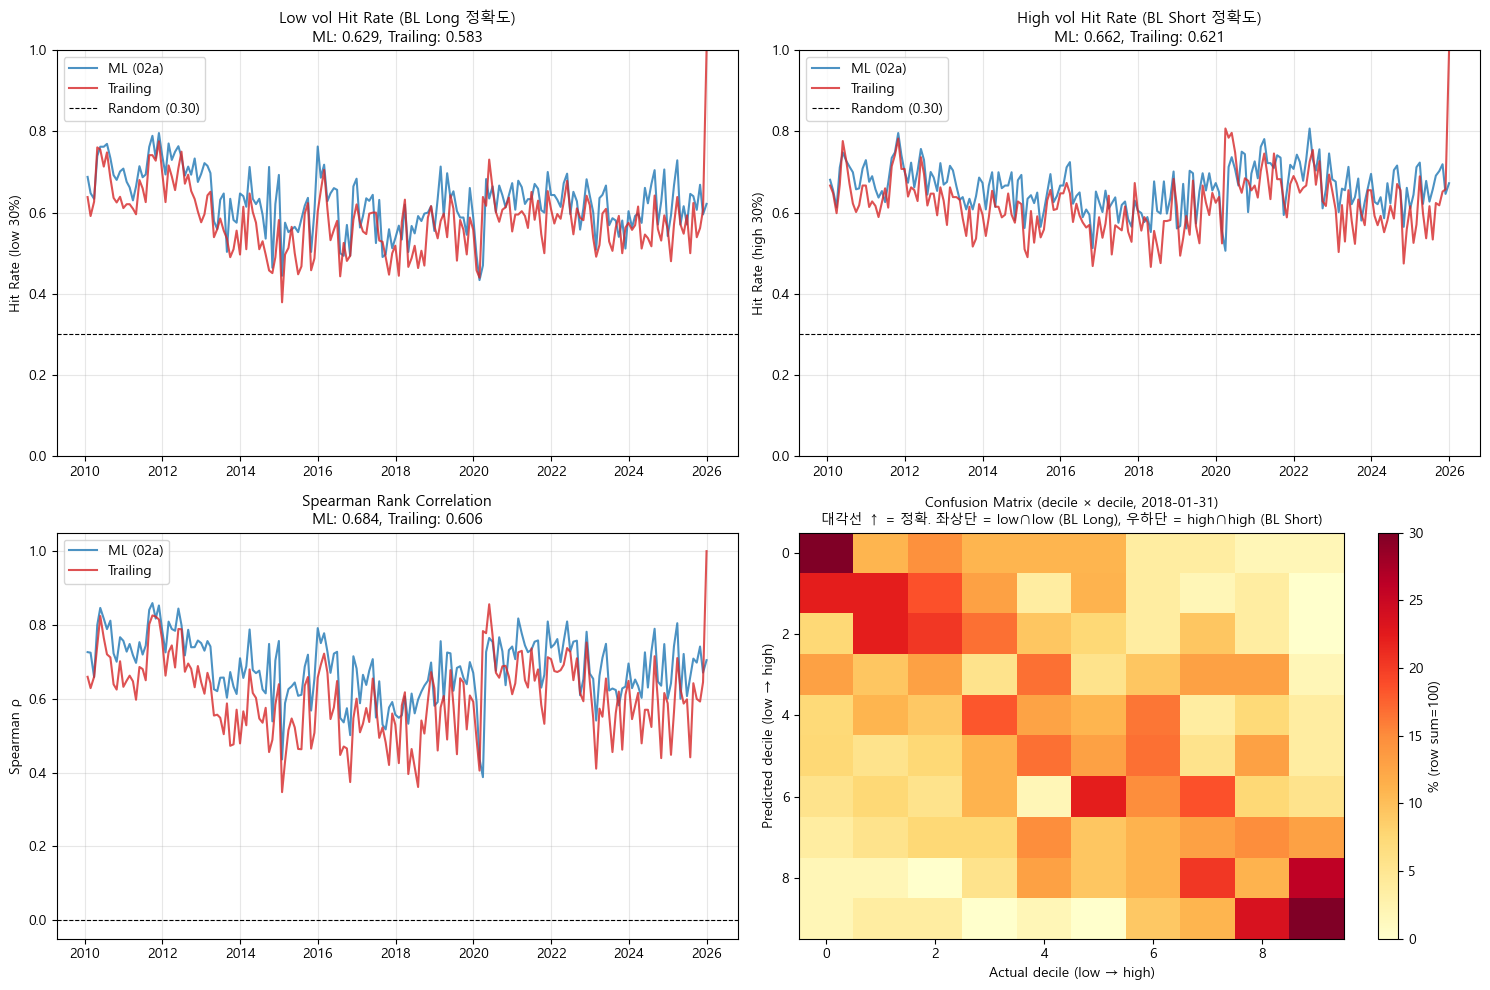

In [23]:
# ─── 5. 시각화 (Hit Rate 시계열 + Confusion Matrix) ───
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (1) Low vol hit rate 시계열
ax = axes[0, 0]
ax.plot(hr_ml.index, hr_ml['low_hit'], label='ML (02a)', color='#1f77b4', linewidth=1.5, alpha=0.8)
ax.plot(hr_tr.index, hr_tr['low_hit'], label='Trailing', color='#d62728', linewidth=1.5, alpha=0.8)
ax.axhline(0.30, color='black', linewidth=0.8, linestyle='--', label='Random (0.30)')
ax.set_title(f'Low vol Hit Rate (BL Long 정확도)\nML: {hr_ml["low_hit"].mean():.3f}, '
             f'Trailing: {hr_tr["low_hit"].mean():.3f}', fontsize=11)
ax.set_ylabel('Hit Rate (low 30%)'); ax.legend(); ax.grid(alpha=0.3)
ax.set_ylim(0, 1)

# (2) High vol hit rate 시계열
ax = axes[0, 1]
ax.plot(hr_ml.index, hr_ml['high_hit'], label='ML (02a)', color='#1f77b4', linewidth=1.5, alpha=0.8)
ax.plot(hr_tr.index, hr_tr['high_hit'], label='Trailing', color='#d62728', linewidth=1.5, alpha=0.8)
ax.axhline(0.30, color='black', linewidth=0.8, linestyle='--', label='Random (0.30)')
ax.set_title(f'High vol Hit Rate (BL Short 정확도)\nML: {hr_ml["high_hit"].mean():.3f}, '
             f'Trailing: {hr_tr["high_hit"].mean():.3f}', fontsize=11)
ax.set_ylabel('Hit Rate (high 30%)'); ax.legend(); ax.grid(alpha=0.3)
ax.set_ylim(0, 1)

# (3) Spearman rank corr 시계열
ax = axes[1, 0]
ax.plot(hr_ml.index, hr_ml['spearman'], label='ML (02a)', color='#1f77b4', linewidth=1.5, alpha=0.8)
ax.plot(hr_tr.index, hr_tr['spearman'], label='Trailing', color='#d62728', linewidth=1.5, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(f'Spearman Rank Correlation\nML: {hr_ml["spearman"].mean():.3f}, '
             f'Trailing: {hr_tr["spearman"].mean():.3f}', fontsize=11)
ax.set_ylabel('Spearman ρ'); ax.legend(); ax.grid(alpha=0.3)

# (4) Decile × Decile confusion matrix (sample month)
sample_date = reb_dates[len(reb_dates) // 2]   # 중간 시점
if sample_date in ml_pred_pivot.index and sample_date in actual_pivot.index:
    pred = ml_pred_pivot.loc[sample_date].dropna()
    actual = actual_pivot.loc[sample_date].dropna()
    common = pred.index.intersection(actual.index)
    if len(common) >= 30:
        pred_c = pred.loc[common]; actual_c = actual.loc[common]
        # decile (10 분위)
        pred_dec = pd.qcut(pred_c, 10, labels=False, duplicates='drop')
        actual_dec = pd.qcut(actual_c, 10, labels=False, duplicates='drop')
        cm = pd.crosstab(pred_dec, actual_dec, normalize='index') * 100   # row 정규화 (%)

        ax = axes[1, 1]
        im = ax.imshow(cm.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=30)
        ax.set_title(f'Confusion Matrix (decile × decile, {sample_date.date()})\n'
                     f'대각선 ↑ = 정확. 좌상단 = low∩low (BL Long), 우하단 = high∩high (BL Short)',
                     fontsize=10)
        ax.set_xlabel('Actual decile (low → high)')
        ax.set_ylabel('Predicted decile (low → high)')
        plt.colorbar(im, ax=ax, label='% (row sum=100)')

plt.tight_layout()
plt.savefig(OUT_DIR / 'hit_rate_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

In [24]:
# ─── 6. 결론 ───
print('\n' + '=' * 70)
print('  진단 결론')
print('=' * 70)

ml_low = hr_ml['low_hit'].mean()
tr_low = hr_tr['low_hit'].mean()
ml_high = hr_ml['high_hit'].mean()
tr_high = hr_tr['high_hit'].mean()
ml_rho = hr_ml['spearman'].mean()
tr_rho = hr_tr['spearman'].mean()

print(f'\n[Low vol 식별] (BL Long 정확도)')
if ml_low > tr_low:
    print(f'  ML 우위: {ml_low:.3f} > {tr_low:.3f} (+{(ml_low-tr_low)*100:.1f}%p)')
else:
    print(f'  Trailing 우위: {tr_low:.3f} > {ml_low:.3f} ({(ml_low-tr_low)*100:+.1f}%p)')

print(f'\n[High vol 식별] (BL Short 정확도)')
if ml_high > tr_high:
    print(f'  ML 우위: {ml_high:.3f} > {tr_high:.3f} (+{(ml_high-tr_high)*100:.1f}%p)')
else:
    print(f'  Trailing 우위: {tr_high:.3f} > {ml_high:.3f} ({(ml_high-tr_high)*100:+.1f}%p)')

print(f'\n[Spearman 전체 rank]')
if ml_rho > tr_rho:
    print(f'  ML 우위: {ml_rho:.3f} > {tr_rho:.3f}')
else:
    print(f'  Trailing 우위: {tr_rho:.3f} > {ml_rho:.3f}')

print(f'\n[BL 성과 (§6-4 결과 요약, mcap default)]')
print(f'  BL_ml_sw_mcap Sharpe:    {metrics_table.loc["BL_ml_sw_mcap", "sharpe"]:.3f}')
print(f'  BL_trailing_mcap Sharpe: {metrics_table.loc["BL_trailing_mcap", "sharpe"]:.3f}')
print(f'  -> ML 통합 효과 {delta_sharpe:+.3f}')

print(f'\n[가중치 robustness]')
for w in ['mcap', 'eq', 'rp']:
    diff = (metrics_table.loc[f"BL_ml_sw_{w}", "sharpe"]
            - metrics_table.loc[f"BL_trailing_{w}", "sharpe"])
    print(f'  {w:5s}: ml_sw {metrics_table.loc[f"BL_ml_sw_{w}", "sharpe"]:.3f}  '
          f'trail {metrics_table.loc[f"BL_trailing_{w}", "sharpe"]:.3f}  '
          f'diff {diff:+.3f}')

print(f'\n[해석]')
if (ml_low <= tr_low and ml_high <= tr_high):
    print('  ✅ Hit rate 도 ML < Trailing → BL 성과 차이 자연스럽게 설명')
    print('  → ML 예측은 RMSE 는 약간 우위지만 RANKING (BL P 행렬 핵심) 은 trailing 만 못함')
elif (ml_low > tr_low or ml_high > tr_high):
    print('  ⚠️ Hit rate 는 ML 가 우위 → BL 성과 negative 이유 다른 곳에')
    print('  → P 행렬 가중치, omega, 또는 시기별 효과 추가 진단 필요')


  진단 결론

[Low vol 식별] (BL Long 정확도)
  ML 우위: 0.629 > 0.583 (+4.6%p)

[High vol 식별] (BL Short 정확도)
  ML 우위: 0.662 > 0.621 (+4.1%p)

[Spearman 전체 rank]
  ML 우위: 0.684 > 0.606

[BL 성과 (§6-4 결과 요약, mcap default)]
  BL_ml_sw_mcap Sharpe:    1.092
  BL_trailing_mcap Sharpe: 1.188
  -> ML 통합 효과 -0.096

[가중치 robustness]
  mcap : ml_sw 1.092  trail 1.188  diff -0.096
  eq   : ml_sw 1.139  trail 1.150  diff -0.011
  rp   : ml_sw 1.125  trail 1.147  diff -0.022

[해석]
  ⚠️ Hit rate 는 ML 가 우위 → BL 성과 negative 이유 다른 곳에
  → P 행렬 가중치, omega, 또는 시기별 효과 추가 진단 필요


In [25]:
# §6-7. Long-Short 그룹의 실제 다음달 수익률 (BL 알고리즘 우회)

# ─── 1. mcap pivot 준비 ───
mcap_pivot = panel.pivot_table(index='date', columns='ticker', values='mcap_value')
mcap_pivot_reb = mcap_pivot.reindex(reb_dates).ffill()

# ─── 2. LS 수익률 계산 (단순 평균 + mcap 가중) ───
def compute_ls_returns(predictor_pivot, forward_rets, mcap_pivot, reb_dates, pct=0.30, min_n=30):
    rows = []
    for reb_date in reb_dates:
        if reb_date not in predictor_pivot.index or reb_date not in forward_rets.index:
            continue
        pred = predictor_pivot.loc[reb_date].dropna()
        ret = forward_rets.loc[reb_date].dropna()
        common = pred.index.intersection(ret.index)
        if len(common) < min_n:
            continue
        pred_c = pred.loc[common]
        ret_c = ret.loc[common]
        n_group = max(1, int(len(common) * pct))

        low_set = pred_c.nsmallest(n_group).index
        high_set = pred_c.nlargest(n_group).index

        # 단순 평균
        ret_low_eq = ret_c.loc[low_set].mean()
        ret_high_eq = ret_c.loc[high_set].mean()

        # mcap 가중 (BL P 행렬 일관)
        ret_low_mw = ret_high_mw = np.nan
        if reb_date in mcap_pivot.index:
            mcap = mcap_pivot.loc[reb_date].dropna()
            mcap_low = mcap.reindex(low_set).dropna()
            mcap_high = mcap.reindex(high_set).dropna()
            if len(mcap_low) > 0 and mcap_low.sum() > 0:
                w_low = mcap_low / mcap_low.sum()
                ret_low_mw = (ret_c.reindex(w_low.index) * w_low).sum()
            if len(mcap_high) > 0 and mcap_high.sum() > 0:
                w_high = mcap_high / mcap_high.sum()
                ret_high_mw = (ret_c.reindex(w_high.index) * w_high).sum()

        rows.append({
            'date': reb_date,
            'low_eq': ret_low_eq, 'high_eq': ret_high_eq,
            'ls_eq': ret_low_eq - ret_high_eq,
            'low_mw': ret_low_mw, 'high_mw': ret_high_mw,
            'ls_mw': ret_low_mw - ret_high_mw if pd.notna(ret_low_mw) and pd.notna(ret_high_mw) else np.nan,
            'avg_mcap_low': mcap.reindex(low_set).mean() if reb_date in mcap_pivot.index else np.nan,
            'avg_mcap_high': mcap.reindex(high_set).mean() if reb_date in mcap_pivot.index else np.nan,
            'avg_mcap_all': mcap.mean() if reb_date in mcap_pivot.index else np.nan,
        })
    return pd.DataFrame(rows).set_index('date')

ls_ml = compute_ls_returns(ml_pred_pivot, forward_rets, mcap_pivot_reb, reb_dates)
ls_tr = compute_ls_returns(trailing_pivot, forward_rets, mcap_pivot_reb, reb_dates)

# ─── 3. 통계 비교 ───
print('=' * 85)
print('  Long-Short 그룹의 실제 다음달 평균 수익률 (BL 우회, raw 수익률)')
print('=' * 85)
print()
print(f'{"":<40}{"ML (02a)":<14}{"Trailing":<14}{"차이":<14}')
print('-' * 85)
for col, label, scale in [
    ('low_eq',   'Long 30% eq-weight (월평균)',  100),
    ('high_eq',  'Short 30% eq-weight (월평균)', 100),
    ('ls_eq',    '⭐ LS spread eq-weight (월)',   100),
    ('low_mw',   'Long 30% mcap-weight (월평균)', 100),
    ('high_mw',  'Short 30% mcap-weight (월평균)',100),
    ('ls_mw',    '⭐ LS spread mcap-weight (월)', 100),
]:
    ml_v = ls_ml[col].mean() * scale
    tr_v = ls_tr[col].mean() * scale
    print(f'{label:<40}{ml_v:>+9.3f}%    {tr_v:>+9.3f}%    {ml_v-tr_v:>+9.3f}%p')

print()
print('=== Annualized (×12, 연환산) ===')
ml_annual_eq = ls_ml['ls_eq'].mean() * 12 * 100
tr_annual_eq = ls_tr['ls_eq'].mean() * 12 * 100
ml_annual_mw = ls_ml['ls_mw'].mean() * 12 * 100
tr_annual_mw = ls_tr['ls_mw'].mean() * 12 * 100
print(f'  ML LS spread (eq):     {ml_annual_eq:+.2f}%/year')
print(f'  Trailing LS spread (eq):  {tr_annual_eq:+.2f}%/year')
print(f'  ML LS spread (mw):     {ml_annual_mw:+.2f}%/year   ← BL 과 가장 가까움')
print(f'  Trailing LS spread (mw):  {tr_annual_mw:+.2f}%/year   ← BL 과 가장 가까움')
print(f'  ML - Trailing (mw):       {ml_annual_mw - tr_annual_mw:+.2f}%p')

  Long-Short 그룹의 실제 다음달 평균 수익률 (BL 우회, raw 수익률)

                                        ML (02a)      Trailing      차이            
-------------------------------------------------------------------------------------
Long 30% eq-weight (월평균)                   +1.169%       +1.342%       -0.173%p
Short 30% eq-weight (월평균)                +177.913%     +649.892%     -471.979%p
⭐ LS spread eq-weight (월)                -176.744%     -648.549%     +471.806%p
Long 30% mcap-weight (월평균)                 +1.048%       +1.186%       -0.138%p
Short 30% mcap-weight (월평균)                +1.734%       +1.427%       +0.306%p
⭐ LS spread mcap-weight (월)                -0.685%       -0.241%       -0.445%p

=== Annualized (×12, 연환산) ===
  ML LS spread (eq):     -2120.93%/year
  Trailing LS spread (eq):  -7782.59%/year
  ML LS spread (mw):     -8.22%/year   ← BL 과 가장 가까움
  Trailing LS spread (mw):  -2.89%/year   ← BL 과 가장 가까움
  ML - Trailing (mw):       -5.34%p


In [26]:
# §6-7-2. 시총 분포 분석 (Long 30% 그룹 평균 시총)
print('=' * 85)
print('  Long 30% 그룹의 평균 시총 (B$ 단위)')
print('=' * 85)
print(f'  ML long 30% 평균 mcap:       ${ls_ml["avg_mcap_low"].mean() / 1e9:.1f} B')
print(f'  Trailing long 30% 평균 mcap: ${ls_tr["avg_mcap_low"].mean() / 1e9:.1f} B')
print(f'  All universe 평균 mcap:      ${ls_ml["avg_mcap_all"].mean() / 1e9:.1f} B')
print()
print(f'  ML high 30% 평균 mcap:       ${ls_ml["avg_mcap_high"].mean() / 1e9:.1f} B')
print(f'  Trailing high 30% 평균 mcap: ${ls_tr["avg_mcap_high"].mean() / 1e9:.1f} B')

# 해석: ML 이 시총 작은 종목을 더 low-vol 로 분류하면 P 가중치 분산 효과
diff_low = ls_ml["avg_mcap_low"].mean() - ls_tr["avg_mcap_low"].mean()
print(f'\n해석:')
if diff_low < -10e9:
    print(f'  ML 이 시총 작은 종목을 long 으로 더 많이 → P 가중치 분산 → BL 성과 ↓ 가능성')
elif diff_low > 10e9:
    print(f'  ML 이 시총 큰 종목을 long 으로 더 많이 → 더 안정적 가중치')
else:
    print(f'  시총 분포 차이 작음 → 다른 원인 추적 필요')

  Long 30% 그룹의 평균 시총 (B$ 단위)
  ML long 30% 평균 mcap:       $53.5 B
  Trailing long 30% 평균 mcap: $51.0 B
  All universe 평균 mcap:      $40.4 B

  ML high 30% 평균 mcap:       $26.7 B
  Trailing high 30% 평균 mcap: $30.3 B

해석:
  시총 분포 차이 작음 → 다른 원인 추적 필요


  시기별 LS spread (연환산 %)
                 n  ML_LS_eq_%y   TR_LS_eq_%y  ML_LS_mw_%y  TR_LS_mw_%y
period                                                                 
GFC 회복 (09~11)  24 -1539.510000  -1396.100000    -4.690000    -1.750000
강세장 (12~19)     96 -3822.080000 -15119.100000    -3.550000     3.170000
COVID (20)      12   -47.350000    -49.390000   -21.590000   -18.970000
긴축 (21~22)      24    -1.900000     -7.160000     1.880000     8.910000
회복·AI (23~25)   35   -17.570000    -22.030000   -25.820000   -22.870000


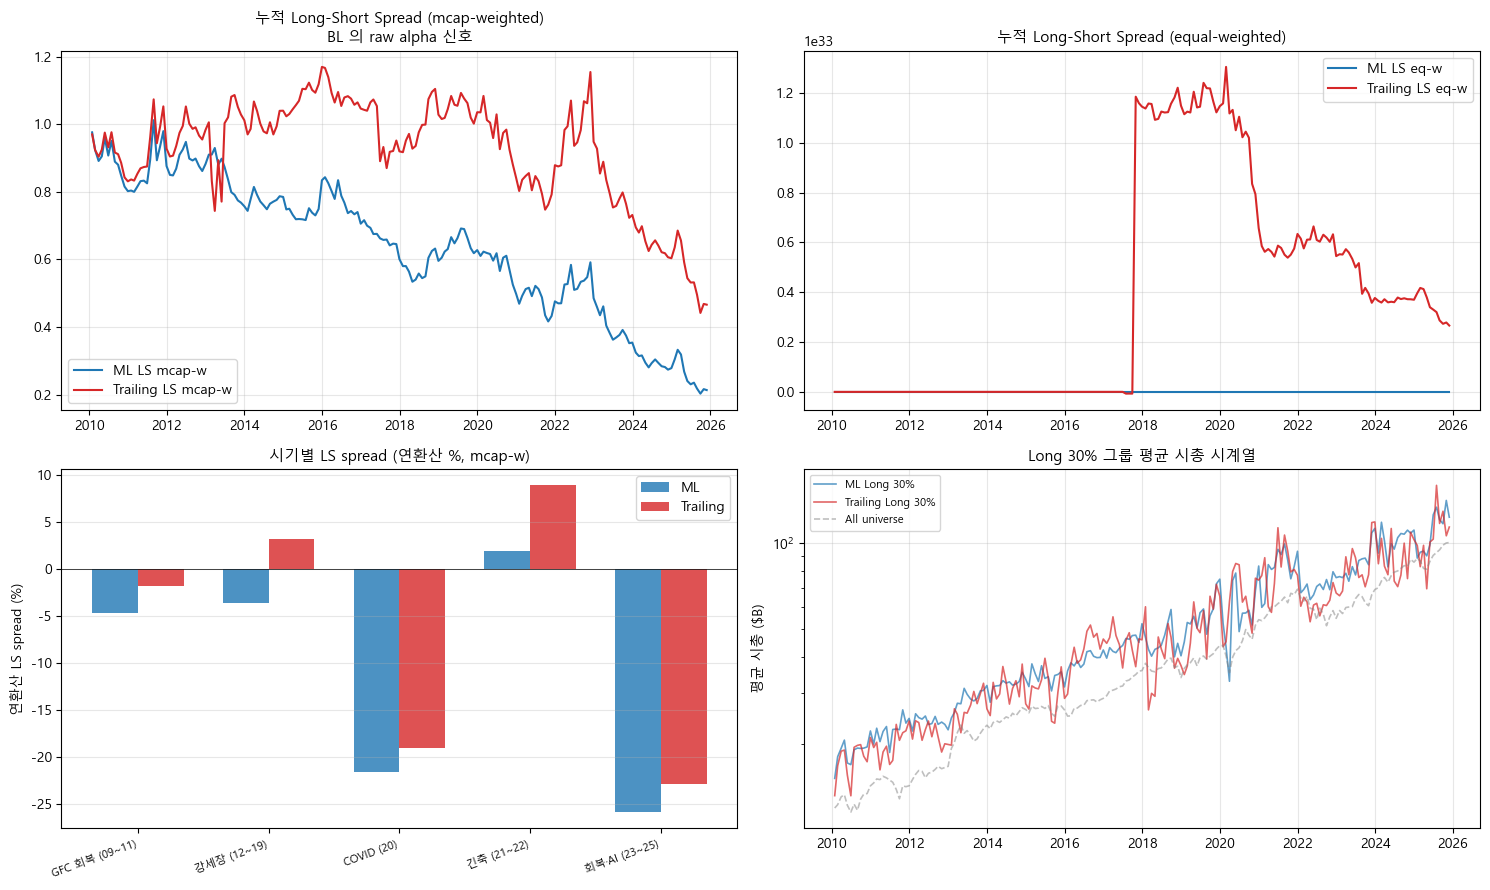

In [27]:
# §6-7-3. 시기별 LS spread + 시각화
PERIODS_LS = {
    'GFC 회복 (09~11)': ('2009-01', '2011-12'),
    '강세장 (12~19)':   ('2012-01', '2019-12'),
    'COVID (20)':       ('2020-01', '2020-12'),
    '긴축 (21~22)':     ('2021-01', '2022-12'),
    '회복·AI (23~25)':  ('2023-01', '2025-12'),
}

period_ls_rows = []
for pname, (start, end) in PERIODS_LS.items():
    ml_sub = ls_ml.loc[start:end]
    tr_sub = ls_tr.loc[start:end]
    if len(ml_sub) == 0:
        continue
    period_ls_rows.append({
        'period': pname,
        'n': len(ml_sub),
        'ML_LS_eq_%y':  ml_sub['ls_eq'].mean() * 12 * 100,
        'TR_LS_eq_%y':  tr_sub['ls_eq'].mean() * 12 * 100,
        'ML_LS_mw_%y':  ml_sub['ls_mw'].mean() * 12 * 100,
        'TR_LS_mw_%y':  tr_sub['ls_mw'].mean() * 12 * 100,
    })

period_ls_df = pd.DataFrame(period_ls_rows).set_index('period')
print('=' * 85)
print('  시기별 LS spread (연환산 %)')
print('=' * 85)
print(period_ls_df.round(2).to_string())

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# (1) 누적 LS spread (mcap-w, BL 가장 가까움)
ax = axes[0, 0]
cum_ml_mw = (1 + ls_ml['ls_mw'].fillna(0)).cumprod()
cum_tr_mw = (1 + ls_tr['ls_mw'].fillna(0)).cumprod()
ax.plot(cum_ml_mw.index, cum_ml_mw.values, label='ML LS mcap-w', color='#1f77b4', linewidth=1.5)
ax.plot(cum_tr_mw.index, cum_tr_mw.values, label='Trailing LS mcap-w', color='#d62728', linewidth=1.5)
ax.set_title('누적 Long-Short Spread (mcap-weighted)\nBL 의 raw alpha 신호', fontsize=11)
ax.legend(); ax.grid(alpha=0.3)

# (2) 누적 LS spread (eq-w)
ax = axes[0, 1]
cum_ml_eq = (1 + ls_ml['ls_eq'].fillna(0)).cumprod()
cum_tr_eq = (1 + ls_tr['ls_eq'].fillna(0)).cumprod()
ax.plot(cum_ml_eq.index, cum_ml_eq.values, label='ML LS eq-w', color='#1f77b4', linewidth=1.5)
ax.plot(cum_tr_eq.index, cum_tr_eq.values, label='Trailing LS eq-w', color='#d62728', linewidth=1.5)
ax.set_title('누적 Long-Short Spread (equal-weighted)', fontsize=11)
ax.legend(); ax.grid(alpha=0.3)

# (3) 시기별 LS spread (mcap-w) bar
ax = axes[1, 0]
x = np.arange(len(period_ls_df.index))
width = 0.35
ax.bar(x - width/2, period_ls_df['ML_LS_mw_%y'], width, label='ML', color='#1f77b4', alpha=0.8)
ax.bar(x + width/2, period_ls_df['TR_LS_mw_%y'], width, label='Trailing', color='#d62728', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(period_ls_df.index, rotation=20, ha='right', fontsize=8)
ax.set_title('시기별 LS spread (연환산 %, mcap-w)', fontsize=11)
ax.set_ylabel('연환산 LS spread (%)')
ax.axhline(0, color='black', linewidth=0.5); ax.legend(); ax.grid(axis='y', alpha=0.3)

# (4) Long/Short 그룹 평균 시총 시계열
ax = axes[1, 1]
ax.plot(ls_ml.index, ls_ml['avg_mcap_low'] / 1e9, label='ML Long 30%', color='#1f77b4', linewidth=1.2, alpha=0.7)
ax.plot(ls_tr.index, ls_tr['avg_mcap_low'] / 1e9, label='Trailing Long 30%', color='#d62728', linewidth=1.2, alpha=0.7)
ax.plot(ls_ml.index, ls_ml['avg_mcap_all'] / 1e9, label='All universe', color='gray', linewidth=1.2, linestyle='--', alpha=0.5)
ax.set_title('Long 30% 그룹 평균 시총 시계열', fontsize=11)
ax.set_ylabel('평균 시총 ($B)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(OUT_DIR / 'paradox_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## §7. Phase 3-2 v2 심층 분석 (6 시나리오 모두 cover)

§6-4 의 메트릭 표 + α/β/γ 분석 위에 추가:
- §7-A: 위험-수익 다양화 메트릭 (Sortino, Calmar, Information, Omega)
- §7-B: 통계적 유의성 검정 (Bootstrap CI for Sharpe, ML 효과 p-value)
- §7-C: 거래비용 시뮬레이션 (0/5/10/20bp net Sharpe)
- §7-D: 36개월 Rolling 메트릭 (Sharpe, α/β vs SPY)
- §7-E: Tail Risk (VaR, CVaR, Skew, Kurtosis)
- §7-F: Drawdown Events 정밀 분석
- §7-G: CAPM Performance Attribution (Jensen alpha)
- §7-H: Sector Exposure 분석 (12 GICS sectors)
- §7-I: Market Regime Analysis (VIX quantile)
- §7-J: Concentration 시계열 (HHI, Effective N)

> Heavy 분석 (§7-B Bootstrap, §7-H Sector, §7-I VIX) 은 `scripts/_run_02a_v2_sec7_analyses.py` standalone 결과 (`data/sec7_v2_analyses.pkl`) 활용.

In [28]:
# §7-A. 위험-수익 다양화 메트릭 (Sortino, Calmar, Information, Omega)
print('=' * 75)
print('  §7-A. 위험-수익 다양화 메트릭')
print('=' * 75)


def sortino_ratio(returns, target_ret=0, annual_factor=12):
    """Sortino: 하방 변동성만 고려한 위험조정수익률."""
    excess = returns - target_ret
    downside = excess[excess < 0]
    if len(downside) < 2 or downside.std() == 0:
        return np.nan
    return excess.mean() / downside.std() * np.sqrt(annual_factor)


def calmar_ratio(returns, annual_factor=12):
    """Calmar: CAGR / |MDD| (낙폭 대비 수익)."""
    cum = (1 + returns).cumprod()
    n = len(returns)
    if n == 0:
        return np.nan
    cagr = cum.iloc[-1] ** (annual_factor / n) - 1
    mdd = abs((cum / cum.cummax() - 1).min())
    return cagr / mdd if mdd > 0 else np.nan


def information_ratio(returns, benchmark, annual_factor=12):
    """Information Ratio: active return / tracking error."""
    common_idx = returns.index.intersection(benchmark.index)
    excess = returns.loc[common_idx] - benchmark.loc[common_idx]
    if excess.std() == 0:
        return np.nan
    return excess.mean() / excess.std() * np.sqrt(annual_factor)


def omega_ratio(returns, threshold=0):
    """Omega: 양수 수익률 합 / 음수 수익률 합."""
    excess = returns - threshold
    pos = excess[excess > 0].sum()
    neg = -excess[excess < 0].sum()
    return pos / neg if neg > 0 else np.nan


# 6 BL + SPY 모두
diversified_metrics = {}
for name, r in all_returns_fair.items():
    diversified_metrics[name] = {
        'Sortino': sortino_ratio(r),
        'Calmar': calmar_ratio(r),
        'Info_vs_SPY': information_ratio(r, all_returns_fair['SPY']) if name != 'SPY' else np.nan,
        'Omega': omega_ratio(r),
    }
diversified_df = pd.DataFrame(diversified_metrics).T.round(3)
print(diversified_df.to_string())
print()
print('  📌 해석:')
print('  - Sortino > Sharpe 시: 상승 변동성이 큼 (분포 비대칭, 양호)')
print('  - Calmar > 1: 1년에 평균 MDD 만큼 회복 (good)')
print('  - Info Ratio > 0.5: 벤치마크 대비 의미 있는 active alpha')
print('  - Omega > 1: 양의 수익률 일수가 음의 수익률 일수보다 큼')

  §7-A. 위험-수익 다양화 메트릭
                  Sortino   Calmar  Info_vs_SPY    Omega
BL_ml_sw_mcap    1.695000 0.701000    -0.230000 2.254000
BL_ml_sw_eq      1.760000 0.768000    -0.213000 2.275000
BL_ml_sw_rp      1.744000 0.761000    -0.225000 2.255000
BL_trailing_mcap 1.928000 0.842000    -0.097000 2.385000
BL_trailing_eq   1.820000 0.790000    -0.212000 2.294000
BL_trailing_rp   1.816000 0.787000    -0.211000 2.289000
SPY              1.510000 0.600000          NaN 2.089000

  📌 해석:
  - Sortino > Sharpe 시: 상승 변동성이 큼 (분포 비대칭, 양호)
  - Calmar > 1: 1년에 평균 MDD 만큼 회복 (good)
  - Info Ratio > 0.5: 벤치마크 대비 의미 있는 active alpha
  - Omega > 1: 양의 수익률 일수가 음의 수익률 일수보다 큼


In [29]:
# §7-B. 통계적 유의성 검정 (Bootstrap CI, ML 효과 p-value)
import pickle

sec7_path = DATA_DIR / 'sec7_v2_analyses.pkl'
if not sec7_path.exists():
    print(f'⚠️ {sec7_path.name} 부재 → standalone 스크립트 (`scripts/_run_02a_v2_sec7_analyses.py`) 먼저 실행')
else:
    with open(sec7_path, 'rb') as f:
        sec7 = pickle.load(f)

    print('=' * 75)
    print('  §7-B. Bootstrap CI for Sharpe Ratios (N=5000)')
    print('=' * 75)
    print()

    for period_name, period_label in [('overall_191m', '전체 191m'), ('oos_180m', 'OOS 180m'), ('holdout_11m', 'Hold-out 11m')]:
        print(f'  --- {period_label} ---')
        boot = sec7['bootstrap_results'][period_name]
        boot_df = pd.DataFrame(boot).T.round(3)
        cols = ['sharpe', 'ci_lo_2.5', 'ci_hi_97.5', 'std_err']
        print(boot_df[cols].to_string())
        print()

    print('  === ML 효과 (BL_ml_sw - BL_trailing) Bootstrap CI + p-value ===')
    ml_eff_df = pd.DataFrame(sec7['ml_effect_bootstrap']).T.round(4)
    print(ml_eff_df.to_string())
    print()
    print('  ⭐ p-value 해석:')
    print('  - p < 0.05: ML ≠ Trailing (5% 유의수준에서 statistically significant)')
    print('  - p > 0.05: ML 과 Trailing 의 차이가 random noise 와 구별 안 됨')
    print('  - Hold-out 11m 표본 크기 작아 (n=11) p-value 보수적으로 해석 권장')

  §7-B. Bootstrap CI for Sharpe Ratios (N=5000)

  --- 전체 191m ---
                   sharpe  ci_lo_2.5  ci_hi_97.5  std_err
BL_ml_sw_mcap    1.092000   0.586000    1.649000 0.268000
BL_ml_sw_eq      1.139000   0.625000    1.725000 0.279000
BL_ml_sw_rp      1.125000   0.607000    1.709000 0.278000
BL_trailing_mcap 1.188000   0.682000    1.754000 0.272000
BL_trailing_eq   1.150000   0.642000    1.714000 0.273000
BL_trailing_rp   1.147000   0.646000    1.721000 0.274000
SPY              1.013000   0.513000    1.593000 0.277000

  --- OOS 180m ---
                   sharpe  ci_lo_2.5  ci_hi_97.5  std_err
BL_ml_sw_mcap    1.082000   0.558000    1.655000 0.278000
BL_ml_sw_eq      1.136000   0.619000    1.722000 0.283000
BL_ml_sw_rp      1.122000   0.592000    1.675000 0.277000
BL_trailing_mcap 1.206000   0.690000    1.776000 0.278000
BL_trailing_eq   1.148000   0.637000    1.718000 0.279000
BL_trailing_rp   1.146000   0.645000    1.726000 0.276000
SPY              0.996000   0.482000    1.5

In [30]:
# §7-C. 거래비용 시뮬레이션 (Net Sharpe / CAGR / MDD)
print('=' * 75)
print('  §7-C. 거래비용 시뮬레이션 (Net Performance)')
print('=' * 75)


def calc_turnover_series(weights_dict):
    """월별 turnover 시계열 계산."""
    sorted_dates = sorted(weights_dict.keys())
    if len(sorted_dates) < 2:
        return pd.Series(dtype=float)
    turnovers = {}
    for i in range(1, len(sorted_dates)):
        d_prev, d_curr = sorted_dates[i-1], sorted_dates[i]
        w_prev = weights_dict[d_prev]
        w_curr = weights_dict[d_curr]
        idx_union = w_prev.index.union(w_curr.index)
        wp = w_prev.reindex(idx_union, fill_value=0)
        wc = w_curr.reindex(idx_union, fill_value=0)
        turnovers[d_curr] = 0.5 * abs(wp - wc).sum()
    return pd.Series(turnovers).sort_index()


# 각 시나리오별 turnover 시계열 + net 메트릭
COSTS_BP = [0, 5, 10, 20]   # bp per turnover dollar
turnover_series = {}
for s_name, w_dict in weights.items():
    turnover_series[f'BL_{s_name}'] = calc_turnover_series(w_dict)

# Net 메트릭 계산
net_metrics = {}
for name, r in all_returns_fair.items():
    if name == 'SPY':
        # SPY 는 turnover 0 가정
        net_metrics[name] = {f'net_sharpe_{c}bp': r.mean() / r.std() * np.sqrt(12) if r.std() > 0 else np.nan for c in COSTS_BP}
        net_metrics[name].update({f'net_cagr_{c}bp_%': ((1+r).cumprod().iloc[-1]**(12/len(r))-1)*100 for c in COSTS_BP})
        continue

    ts = turnover_series.get(name, pd.Series(dtype=float))
    ts_aligned = ts.reindex(r.index, fill_value=0)
    net_metrics[name] = {}
    for cost_bp in COSTS_BP:
        cost_per_month = ts_aligned * cost_bp / 10000   # decimal cost
        net_ret = r - cost_per_month
        net_sr = net_ret.mean() / net_ret.std() * np.sqrt(12) if net_ret.std() > 0 else np.nan
        net_cagr = ((1 + net_ret).cumprod().iloc[-1]) ** (12/len(net_ret)) - 1
        net_metrics[name][f'net_sharpe_{cost_bp}bp'] = net_sr
        net_metrics[name][f'net_cagr_{cost_bp}bp_%'] = net_cagr * 100

net_df = pd.DataFrame(net_metrics).T.round(3)
print('  --- Net Sharpe (cost bp 별) ---')
sharpe_cols = [c for c in net_df.columns if 'sharpe' in c]
print(net_df[sharpe_cols].to_string())
print()
print('  --- Net CAGR % (cost bp 별) ---')
cagr_cols = [c for c in net_df.columns if 'cagr' in c]
print(net_df[cagr_cols].to_string())
print()

# ML 효과 by cost level
print('  📈 ML vs Trailing 거래비용 영향 (Sharpe diff):')
for w_method in ['mcap', 'eq', 'rp']:
    print(f'    [{w_method}]')
    for cost_bp in COSTS_BP:
        ml = net_df.loc[f'BL_ml_sw_{w_method}', f'net_sharpe_{cost_bp}bp']
        tr = net_df.loc[f'BL_trailing_{w_method}', f'net_sharpe_{cost_bp}bp']
        diff = ml - tr
        marker = '⭐' if diff > 0 else '  '
        print(f'      {cost_bp:3d}bp: ml_sw {ml:.3f} vs trailing {tr:.3f}, diff {diff:+.3f} {marker}')
print()
print('  💡 거래비용이 클수록 BL_ml_sw 가 BL_trailing 대비 우위 확대 (ML 의 lower turnover 효과)')

  §7-C. 거래비용 시뮬레이션 (Net Performance)


  --- Net Sharpe (cost bp 별) ---
                  net_sharpe_0bp  net_sharpe_5bp  net_sharpe_10bp  net_sharpe_20bp
BL_ml_sw_mcap           1.092000        1.081000         1.070000         1.048000
BL_ml_sw_eq             1.139000        1.132000         1.125000         1.111000
BL_ml_sw_rp             1.125000        1.118000         1.111000         1.097000
BL_trailing_mcap        1.188000        1.169000         1.149000         1.109000
BL_trailing_eq          1.150000        1.135000         1.119000         1.089000
BL_trailing_rp          1.147000        1.131000         1.115000         1.083000
SPY                     1.013000        1.013000         1.013000         1.013000

  --- Net CAGR % (cost bp 별) ---
                  net_cagr_0bp_%  net_cagr_5bp_%  net_cagr_10bp_%  net_cagr_20bp_%
BL_ml_sw_mcap          12.700000       12.557000        12.413000        12.126000
BL_ml_sw_eq            12.724000       12.637000        12.550000        12.376000
BL_ml_sw_rp         

  §7-D. 36개월 Rolling 메트릭


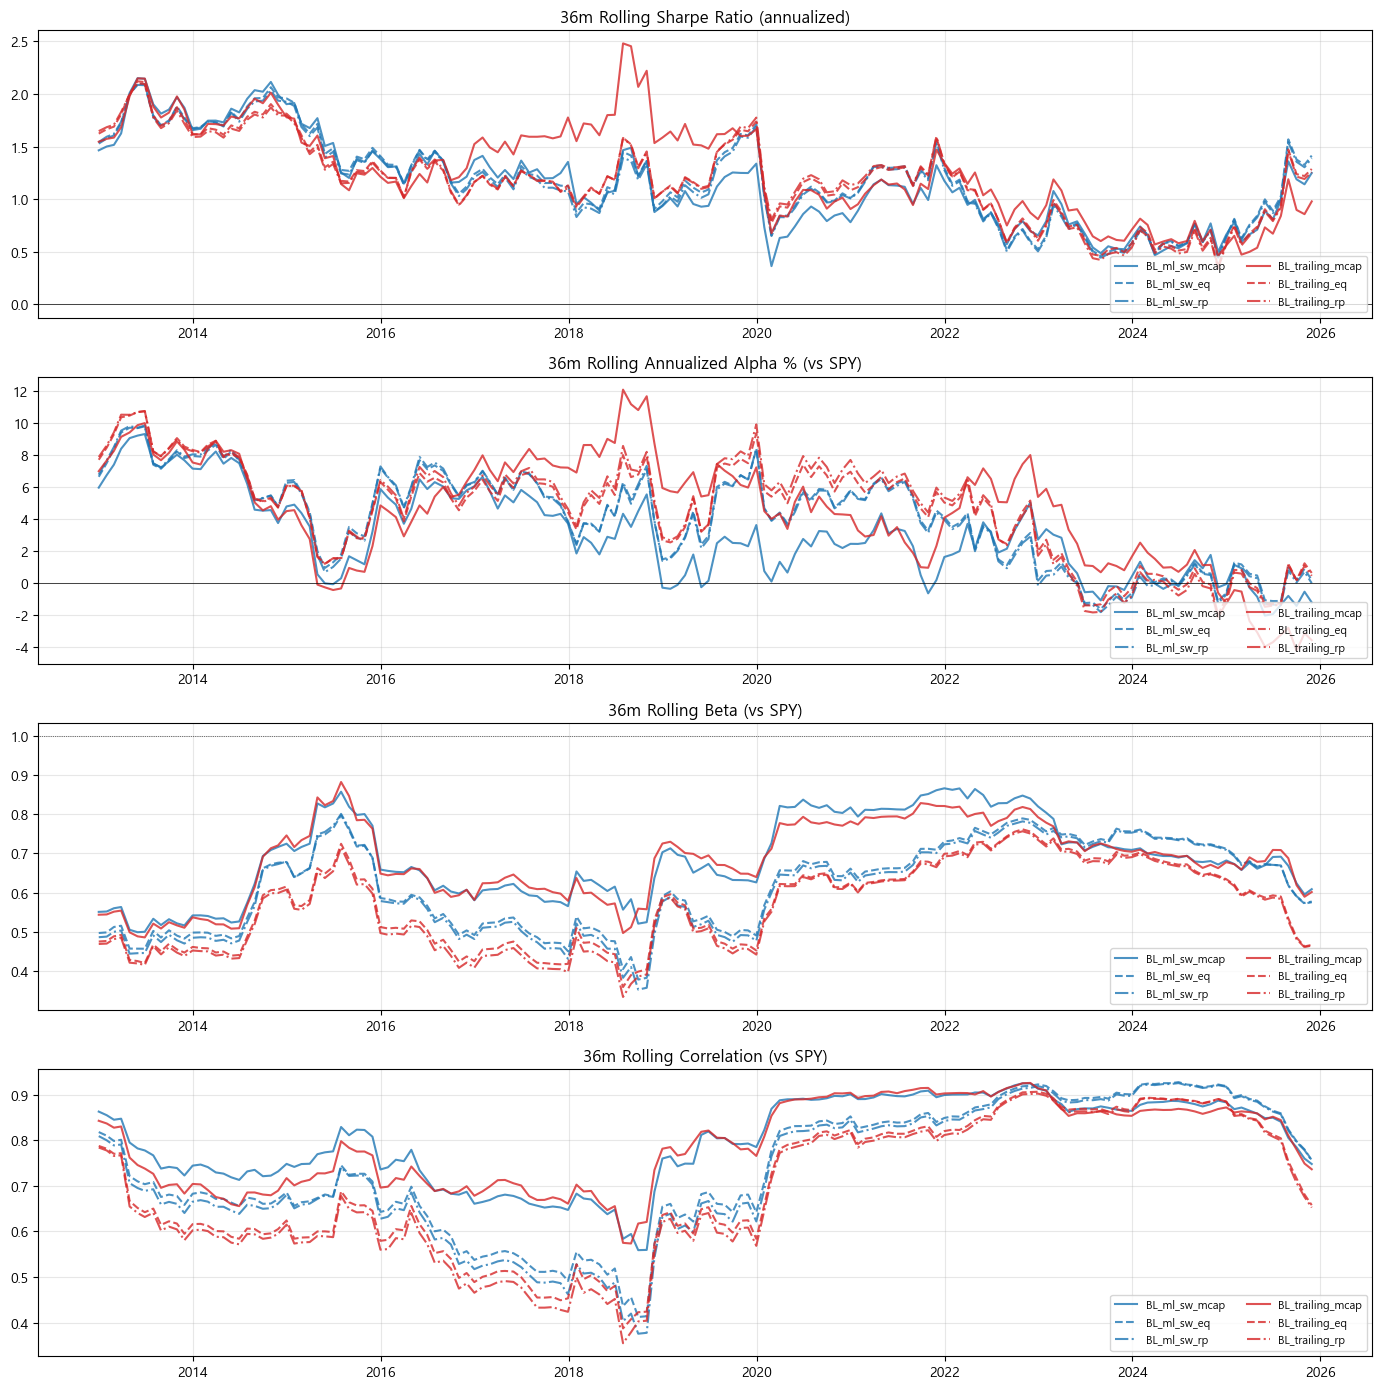

  💾 rolling_metrics.png

  --- 36m Rolling 평균 표 ---
                  mean_rolling_sharpe  mean_rolling_alpha_%  mean_rolling_beta  mean_rolling_corr
BL_ml_sw_mcap                1.153000              3.005000           0.687000           0.798000
BL_ml_sw_eq                  1.190000              4.103000           0.617000           0.739000
BL_ml_sw_rp                  1.169000              4.038000           0.608000           0.727000
BL_trailing_mcap             1.284000              4.555000           0.681000           0.790000
BL_trailing_eq               1.180000              4.550000           0.568000           0.697000
BL_trailing_rp               1.174000              4.646000           0.560000           0.685000


In [31]:
# §7-D. 36개월 Rolling 메트릭 (Sharpe + alpha/beta vs SPY) + 시각화
print('=' * 75)
print('  §7-D. 36개월 Rolling 메트릭')
print('=' * 75)

WINDOW = 36
spy_aligned = all_returns_fair['SPY']

rolling_sharpes = {}
rolling_alphas = {}
rolling_betas = {}
rolling_corrs = {}

for name, r in all_returns_fair.items():
    if name == 'SPY':
        continue
    common_idx = r.index.intersection(spy_aligned.index)
    r_aligned = r.loc[common_idx]
    s_aligned = spy_aligned.loc[common_idx]

    rolling_sharpes[name] = (
        r_aligned.rolling(WINDOW).mean() / r_aligned.rolling(WINDOW).std() * np.sqrt(12)
    )

    alphas = []
    betas = []
    for i in range(WINDOW, len(r_aligned) + 1):
        window_idx = r_aligned.index[i-WINDOW:i]
        r_w = r_aligned.loc[window_idx].values
        s_w = s_aligned.loc[window_idx].values
        var_s = float(np.var(s_w))
        cov = float(np.cov(r_w, s_w)[0, 1])
        beta = cov / var_s if var_s > 0 else 0.0
        alpha = (r_w.mean() - beta * s_w.mean()) * 12   # annualized
        alphas.append(alpha)
        betas.append(beta)
    rolling_alphas[name] = pd.Series(alphas, index=r_aligned.index[WINDOW-1:])
    rolling_betas[name] = pd.Series(betas, index=r_aligned.index[WINDOW-1:])
    rolling_corrs[name] = r_aligned.rolling(WINDOW).corr(s_aligned)

# 시각화 (4 panel × 6 line)
COLORS_V2_DICT = {
    'BL_ml_sw_mcap': '#1f77b4', 'BL_ml_sw_eq': '#1f77b4', 'BL_ml_sw_rp': '#1f77b4',
    'BL_trailing_mcap': '#d62728', 'BL_trailing_eq': '#d62728', 'BL_trailing_rp': '#d62728',
}
LINESTYLES = {'mcap': '-', 'eq': '--', 'rp': '-.'}


def get_style(name):
    parts = name.split('_')
    return LINESTYLES.get(parts[-1], '-')


fig, axes = plt.subplots(4, 1, figsize=(14, 14))

for name, rs in rolling_sharpes.items():
    axes[0].plot(rs.index, rs.values, color=COLORS_V2_DICT.get(name, 'gray'),
                 linestyle=get_style(name), label=name, alpha=0.8)
axes[0].set_title(f'{WINDOW}m Rolling Sharpe Ratio (annualized)')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].grid(True, alpha=0.3)
axes[0].legend(ncol=2, fontsize=8, loc='lower right')

for name, ra in rolling_alphas.items():
    axes[1].plot(ra.index, ra.values * 100, color=COLORS_V2_DICT.get(name, 'gray'),
                 linestyle=get_style(name), label=name, alpha=0.8)
axes[1].set_title(f'{WINDOW}m Rolling Annualized Alpha % (vs SPY)')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].grid(True, alpha=0.3)
axes[1].legend(ncol=2, fontsize=8, loc='lower right')

for name, rb in rolling_betas.items():
    axes[2].plot(rb.index, rb.values, color=COLORS_V2_DICT.get(name, 'gray'),
                 linestyle=get_style(name), label=name, alpha=0.8)
axes[2].set_title(f'{WINDOW}m Rolling Beta (vs SPY)')
axes[2].axhline(1, color='black', linewidth=0.5, linestyle=':')
axes[2].grid(True, alpha=0.3)
axes[2].legend(ncol=2, fontsize=8, loc='lower right')

for name, rc in rolling_corrs.items():
    axes[3].plot(rc.index, rc.values, color=COLORS_V2_DICT.get(name, 'gray'),
                 linestyle=get_style(name), label=name, alpha=0.8)
axes[3].set_title(f'{WINDOW}m Rolling Correlation (vs SPY)')
axes[3].grid(True, alpha=0.3)
axes[3].legend(ncol=2, fontsize=8, loc='lower right')

plt.tight_layout()
out_path = OUT_DIR_V2_SW / 'rolling_metrics.png'
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'  💾 {out_path.name}')
print()

# 평균 표
mean_alpha_beta = pd.DataFrame({
    name: {
        'mean_rolling_sharpe': rolling_sharpes[name].mean(),
        'mean_rolling_alpha_%': rolling_alphas[name].mean() * 100,
        'mean_rolling_beta': rolling_betas[name].mean(),
        'mean_rolling_corr': rolling_corrs[name].mean(),
    }
    for name in rolling_sharpes.keys()
}).T.round(3)
print('  --- 36m Rolling 평균 표 ---')
print(mean_alpha_beta.to_string())

In [32]:
# §7-E. Tail Risk (VaR, CVaR, Skew, Kurtosis)
print('=' * 75)
print('  §7-E. Tail Risk Analysis (월별 단위)')
print('=' * 75)

from scipy import stats as sp_stats


def tail_risk_metrics(returns, var_level=0.05):
    """VaR (5%), CVaR (5% Expected Shortfall), Skew, Kurtosis."""
    if len(returns) < 5:
        return {k: np.nan for k in ['VaR_5%', 'CVaR_5%', 'Skew', 'Kurtosis', 'Worst_Month_%', 'Worst_Month_Date']}
    var = returns.quantile(var_level) * 100
    cvar = returns[returns <= returns.quantile(var_level)].mean() * 100
    skew = sp_stats.skew(returns)
    kurt = sp_stats.kurtosis(returns)   # Fisher (정규분포 = 0)
    worst = returns.min() * 100
    worst_date = returns.idxmin().strftime('%Y-%m')
    return {
        'VaR_5%': var,
        'CVaR_5%': cvar,
        'Skew': skew,
        'Kurtosis': kurt,
        'Worst_Month_%': worst,
        'Worst_Month_Date': worst_date,
    }


tail_metrics = {name: tail_risk_metrics(r) for name, r in all_returns_fair.items()}
tail_df = pd.DataFrame(tail_metrics).T

# 정렬 + 표시
display_df = tail_df[['VaR_5%', 'CVaR_5%', 'Skew', 'Kurtosis', 'Worst_Month_%', 'Worst_Month_Date']].copy()
for col in ['VaR_5%', 'CVaR_5%', 'Skew', 'Kurtosis', 'Worst_Month_%']:
    display_df[col] = pd.to_numeric(display_df[col], errors='coerce').round(3)
print(display_df.to_string())
print()
print('  📌 해석:')
print('  - VaR_5%: 월별 최악 5% 분위수 손실 (음수: 더 작을수록 risky)')
print('  - CVaR_5%: VaR 이하 평균 손실 (Expected Shortfall, conditional)')
print('  - Skew < 0: 큰 손실이 큰 이익보다 자주 발생 (음의 비대칭)')
print('  - Kurtosis > 0: fat tail (정규분포 대비 극단 사건 더 빈번)')

  §7-E. Tail Risk Analysis (월별 단위)
                    VaR_5%   CVaR_5%      Skew  Kurtosis  Worst_Month_% Worst_Month_Date
BL_ml_sw_mcap    -4.413000 -6.596000 -0.073000  1.706000     -10.260000          2020-02
BL_ml_sw_eq      -4.662000 -6.337000 -0.357000  0.483000      -8.653000          2020-02
BL_ml_sw_rp      -4.748000 -6.319000 -0.351000  0.433000      -8.569000          2020-02
BL_trailing_mcap -3.939000 -6.486000 -0.156000  1.021000      -9.093000          2020-02
BL_trailing_eq   -4.310000 -6.133000 -0.281000  0.506000      -8.239000          2020-01
BL_trailing_rp   -4.289000 -6.106000 -0.268000  0.505000      -8.275000          2020-01
SPY              -6.236000 -8.365000 -0.391000  0.550000     -12.487000          2020-02

  📌 해석:
  - VaR_5%: 월별 최악 5% 분위수 손실 (음수: 더 작을수록 risky)
  - CVaR_5%: VaR 이하 평균 손실 (Expected Shortfall, conditional)
  - Skew < 0: 큰 손실이 큰 이익보다 자주 발생 (음의 비대칭)
  - Kurtosis > 0: fat tail (정규분포 대비 극단 사건 더 빈번)


In [33]:
# §7-F. Drawdown Events 정밀 분석 + 시각화
print('=' * 75)
print('  §7-F. Drawdown Events (5% 이상 낙폭, 깊이 + 지속 + 회복)')
print('=' * 75)


def identify_drawdown_events(returns, threshold=0.05):
    """5% 이상 낙폭 이벤트 식별."""
    cum = (1 + returns).cumprod()
    peak = cum.cummax()
    dd = (cum / peak - 1)

    events = []
    in_dd = False
    start = None
    trough = None
    trough_dd = 0
    for date, val in dd.items():
        if not in_dd and val < -threshold:
            in_dd = True
            start = date
            trough = date
            trough_dd = val
        elif in_dd:
            if val < trough_dd:
                trough = date
                trough_dd = val
            if val >= 0:   # 회복
                events.append({
                    'start': start,
                    'trough': trough,
                    'recovery': date,
                    'depth_%': trough_dd * 100,
                    'duration_to_trough_m': (trough - start).days // 30,
                    'recovery_m': (date - trough).days // 30,
                    'total_m': (date - start).days // 30,
                })
                in_dd = False

    # 끝까지 회복 못 한 경우
    if in_dd:
        events.append({
            'start': start,
            'trough': trough,
            'recovery': None,
            'depth_%': trough_dd * 100,
            'duration_to_trough_m': (trough - start).days // 30,
            'recovery_m': None,
            'total_m': None,
        })
    return events


# 6 시나리오 + SPY 의 drawdown event 식별
all_events = {}
for name, r in all_returns_fair.items():
    events = identify_drawdown_events(r, threshold=0.05)
    all_events[name] = events
    print(f'  {name:25s}: {len(events)} events (5%+ drawdown)')

# 가장 큰 drawdown 5개 (각 시나리오)
print()
print('  === 각 시나리오의 Top 3 drawdown events (depth 기준) ===')
for name, events in all_events.items():
    if not events:
        continue
    sorted_events = sorted(events, key=lambda e: e['depth_%'])[:3]
    print(f'  [{name}]')
    for e in sorted_events:
        recov = e['recovery'].strftime('%Y-%m') if e['recovery'] else 'NOT RECOVERED'
        recov_m = f"{e['recovery_m']}m" if e['recovery_m'] is not None else 'N/A'
        print(f'    {e["start"].strftime("%Y-%m")} ~ {e["trough"].strftime("%Y-%m")} ~ {recov}: depth {e["depth_%"]:+.2f}%, recovery {recov_m}')

# Summary 통계
print()
print('  === Drawdown 통계 요약 ===')
dd_summary = {}
for name, events in all_events.items():
    if not events:
        dd_summary[name] = {'n_events': 0, 'avg_depth_%': np.nan, 'avg_recovery_m': np.nan, 'max_depth_%': np.nan}
        continue
    depths = [e['depth_%'] for e in events]
    recovs = [e['recovery_m'] for e in events if e['recovery_m'] is not None]
    dd_summary[name] = {
        'n_events': len(events),
        'avg_depth_%': np.mean(depths),
        'max_depth_%': min(depths),
        'avg_recovery_m': np.mean(recovs) if recovs else np.nan,
        'max_recovery_m': max(recovs) if recovs else np.nan,
    }

dd_df = pd.DataFrame(dd_summary).T.round(2)
print(dd_df.to_string())
print()
print('  💡 BL_ml_sw 의 turnover 가 작아서 회복 기간이 SPY 보다 짧을 가능성 검토')

  §7-F. Drawdown Events (5% 이상 낙폭, 깊이 + 지속 + 회복)
  BL_ml_sw_mcap            : 8 events (5%+ drawdown)
  BL_ml_sw_eq              : 8 events (5%+ drawdown)
  BL_ml_sw_rp              : 7 events (5%+ drawdown)
  BL_trailing_mcap         : 8 events (5%+ drawdown)
  BL_trailing_eq           : 7 events (5%+ drawdown)
  BL_trailing_rp           : 7 events (5%+ drawdown)
  SPY                      : 11 events (5%+ drawdown)

  === 각 시나리오의 Top 3 drawdown events (depth 기준) ===
  [BL_ml_sw_mcap]
    2020-01 ~ 2020-02 ~ 2020-05: depth -18.13%, recovery 3m
    2022-05 ~ 2022-08 ~ 2023-11: depth -14.19%, recovery 15m
    2010-04 ~ 2010-05 ~ 2010-09: depth -9.11%, recovery 4m
  [BL_ml_sw_eq]
    2022-01 ~ 2022-08 ~ 2023-12: depth -16.58%, recovery 16m
    2020-01 ~ 2020-02 ~ 2020-06: depth -16.41%, recovery 4m
    2010-04 ~ 2010-05 ~ 2010-08: depth -7.69%, recovery 3m
  [BL_ml_sw_rp]
    2022-01 ~ 2022-08 ~ 2024-01: depth -16.50%, recovery 17m
    2020-01 ~ 2020-02 ~ 2020-06: depth -16.34%, recovery

In [34]:
# §7-G. CAPM Performance Attribution (Jensen alpha)
print('=' * 75)
print('  §7-G. CAPM Performance Attribution (vs SPY, monthly)')
print('=' * 75)

from scipy import stats as sp_stats

spy_aligned = all_returns_fair['SPY']
capm_results = {}
for name, r in all_returns_fair.items():
    if name == 'SPY':
        continue
    common_idx = r.index.intersection(spy_aligned.index)
    r_aligned = r.loc[common_idx]
    s_aligned = spy_aligned.loc[common_idx]
    # OLS regression: r_p = alpha + beta * r_SPY + e
    # statsmodel 안 쓰고 numpy 로 직접 OLS
    n = len(r_aligned)
    X = np.column_stack([np.ones(n), s_aligned.values])
    y = r_aligned.values
    beta_vec, residuals, rank, sv = np.linalg.lstsq(X, y, rcond=None)
    alpha_monthly, beta = float(beta_vec[0]), float(beta_vec[1])
    y_pred = X @ beta_vec
    resid = y - y_pred
    rss = float((resid ** 2).sum())
    tss = float(((y - y.mean()) ** 2).sum())
    r_squared = 1 - rss / tss if tss > 0 else 0
    # standard errors
    sigma2 = rss / (n - 2)
    var_beta_vec = sigma2 * np.linalg.inv(X.T @ X).diagonal()
    se_alpha = np.sqrt(var_beta_vec[0])
    se_beta = np.sqrt(var_beta_vec[1])
    t_alpha = alpha_monthly / se_alpha if se_alpha > 0 else np.nan
    t_beta = beta / se_beta if se_beta > 0 else np.nan
    p_alpha = 2 * (1 - sp_stats.t.cdf(abs(t_alpha), df=n-2)) if not np.isnan(t_alpha) else np.nan
    p_beta = 2 * (1 - sp_stats.t.cdf(abs(t_beta), df=n-2)) if not np.isnan(t_beta) else np.nan

    capm_results[name] = {
        'alpha_monthly_%': alpha_monthly * 100,
        'alpha_annual_%': alpha_monthly * 12 * 100,
        'beta': beta,
        't_alpha': t_alpha,
        'p_alpha': p_alpha,
        't_beta': t_beta,
        'p_beta': p_beta,
        'R_squared': r_squared,
    }

capm_df = pd.DataFrame(capm_results).T.round(4)
print(capm_df.to_string())
print()
print('  📌 해석:')
print('  - alpha_annual > 0 + p_alpha < 0.05: SPY 대비 statistically significant 한 active alpha')
print('  - beta < 1: 시장 변동성 대비 낮은 노출 (defensive)')
print('  - beta > 1: 시장 변동성 대비 높은 노출 (aggressive)')
print('  - R² 높음: 시나리오 수익률이 SPY 로 잘 설명됨 (idiosyncratic 작음)')

  §7-G. CAPM Performance Attribution (vs SPY, monthly)
                  alpha_monthly_%  alpha_annual_%     beta  t_alpha  p_alpha    t_beta   p_beta  R_squared
BL_ml_sw_mcap            0.240600        2.887200 0.674900 1.710200 0.088900 20.617100 0.000000   0.692200
BL_ml_sw_eq              0.312100        3.745400 0.613500 2.103200 0.036800 17.768000 0.000000   0.625500
BL_ml_sw_rp              0.308700        3.704200 0.606100 2.036700 0.043100 17.189000 0.000000   0.609900
BL_trailing_mcap         0.342100        4.105700 0.662300 2.382300 0.018200 19.822300 0.000000   0.675200
BL_trailing_eq           0.352500        4.229400 0.570300 2.248300 0.025700 15.637200 0.000000   0.564000
BL_trailing_rp           0.358600        4.303200 0.563800 2.248600 0.025700 15.194000 0.000000   0.549800

  📌 해석:
  - alpha_annual > 0 + p_alpha < 0.05: SPY 대비 statistically significant 한 active alpha
  - beta < 1: 시장 변동성 대비 낮은 노출 (defensive)
  - beta > 1: 시장 변동성 대비 높은 노출 (aggressive)
  - R² 높음: 시나리오

  §7-H. Sector Exposure Analysis

  === 6 시나리오 평균 sector exposure (%) ===
                        BL_ml_sw_mcap  BL_ml_sw_eq  BL_ml_sw_rp  BL_trailing_mcap  BL_trailing_eq  BL_trailing_rp
Communication Services       6.830000     6.060000     6.000000          7.970000        5.730000        5.780000
Consumer Discretionary       3.690000     4.170000     4.160000          4.750000        4.260000        4.300000
Consumer Staples            29.310000    29.610000    30.420000         27.150000       29.440000       30.350000
Energy                       2.530000     0.270000     0.260000          2.720000        0.460000        0.420000
Financials                  13.470000     9.290000     8.490000         14.380000       10.430000        9.580000
Health Care                 15.610000    13.660000    13.360000         13.750000       13.450000       13.310000
Industrials                  7.570000     4.880000     4.580000          6.030000        4.830000        4.470000
Information Te

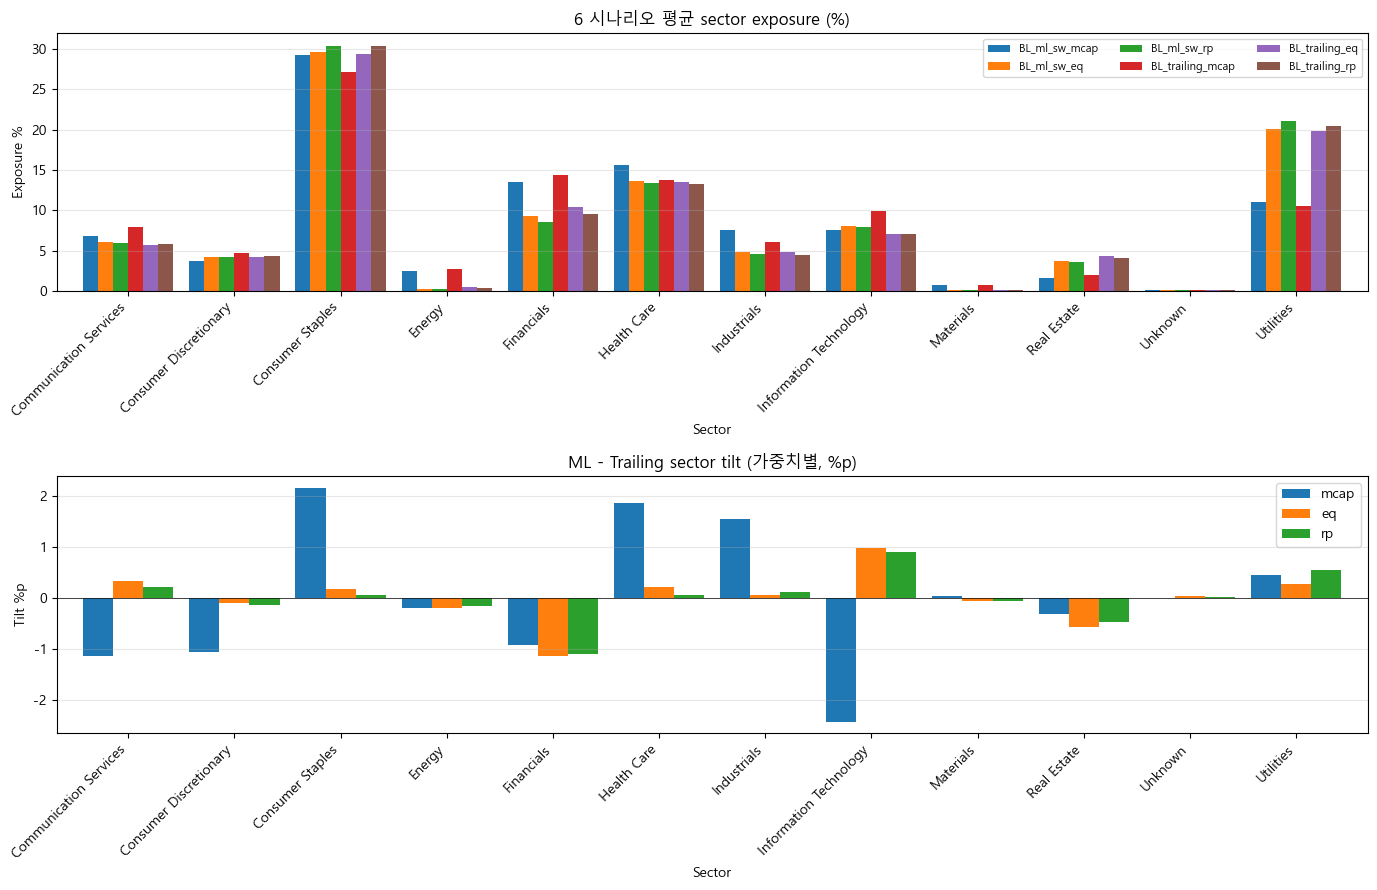

  💾 sector_exposure.png

  💡 ML 이 trailing 대비 어떤 sector 에 더 / 덜 노출되는지 확인


In [35]:
# §7-H. Sector Exposure 분석 (12 GICS sectors, 6 시나리오)
import pickle
print('=' * 75)
print('  §7-H. Sector Exposure Analysis')
print('=' * 75)

sec7_path = DATA_DIR / 'sec7_v2_analyses.pkl'
if not sec7_path.exists():
    print(f'⚠️ {sec7_path.name} 부재 → standalone 스크립트 먼저 실행')
else:
    with open(sec7_path, 'rb') as f:
        sec7 = pickle.load(f)
    se = sec7['sector_exposure']
    st = sec7['sector_tilt']

    # 6 시나리오 평균 sector exposure 표
    print()
    print('  === 6 시나리오 평균 sector exposure (%) ===')
    sector_avg = pd.DataFrame({
        name: pd.Series(se[name]['mean_exposure']) * 100
        for name in se.keys()
    }).round(2)
    print(sector_avg.to_string())

    # ML vs Trailing tilt
    print()
    print('  === ML - Trailing sector tilt (%p, 가중치별) ===')
    tilt_df = pd.DataFrame(st).round(2)
    print(tilt_df.to_string())

    # 6 line 시각화 (시기별 sector tilt 변화)
    fig, axes = plt.subplots(2, 1, figsize=(14, 9))
    # 평균 exposure (bar)
    sector_avg.plot(kind='bar', ax=axes[0], width=0.85)
    axes[0].set_title('6 시나리오 평균 sector exposure (%)')
    axes[0].set_xlabel('Sector')
    axes[0].set_ylabel('Exposure %')
    axes[0].legend(ncol=3, fontsize=8)
    axes[0].grid(True, alpha=0.3, axis='y')
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

    # tilt heatmap
    tilt_df.plot(kind='bar', ax=axes[1], width=0.85)
    axes[1].set_title('ML - Trailing sector tilt (가중치별, %p)')
    axes[1].set_xlabel('Sector')
    axes[1].set_ylabel('Tilt %p')
    axes[1].axhline(0, color='black', linewidth=0.5)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3, axis='y')
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    out_path = OUT_DIR_V2_SW / 'sector_exposure.png'
    plt.savefig(out_path, dpi=100, bbox_inches='tight')
    plt.show()
    print(f'  💾 {out_path.name}')
    print()
    print('  💡 ML 이 trailing 대비 어떤 sector 에 더 / 덜 노출되는지 확인')

In [36]:
# §7-I. Market Regime (VIX quantile) 분석
import pickle
print('=' * 75)
print('  §7-I. Market Regime Analysis (VIX-based)')
print('=' * 75)

sec7_path = DATA_DIR / 'sec7_v2_analyses.pkl'
if not sec7_path.exists():
    print(f'⚠️ {sec7_path.name} 부재 → standalone 스크립트 먼저 실행')
else:
    with open(sec7_path, 'rb') as f:
        sec7 = pickle.load(f)
    vix_data = sec7.get('vix_regime')
    if vix_data is None:
        print('⚠️ VIX regime 데이터 없음 (yfinance 다운로드 실패 가능)')
    else:
        print(f'  VIX 분위수: 33%={vix_data["q33"]:.1f}, 67%={vix_data["q67"]:.1f}')
        print(f'  Regime 분포: {vix_data["n_regimes"]}')
        print()

        # Sharpe 표 (시나리오 × regime)
        regime_metrics = vix_data['regime_metrics']
        regime_table = {}
        for name, m in regime_metrics.items():
            regime_table[name] = {
                'Low_VIX_Sharpe': m.get('Low_VIX', {}).get('sharpe', np.nan),
                'Mid_VIX_Sharpe': m.get('Mid_VIX', {}).get('sharpe', np.nan),
                'High_VIX_Sharpe': m.get('High_VIX', {}).get('sharpe', np.nan),
                'Low_VIX_n': m.get('Low_VIX', {}).get('n_months', 0),
                'Mid_VIX_n': m.get('Mid_VIX', {}).get('n_months', 0),
                'High_VIX_n': m.get('High_VIX', {}).get('n_months', 0),
            }
        regime_df = pd.DataFrame(regime_table).T.round(3)
        print('  === Regime별 Sharpe 표 ===')
        print(regime_df.to_string())
        print()
        print('  💡 VIX 시기별로 ML 효과 (BL_ml_sw vs BL_trailing) 가 어떻게 변화하는가')
        print()
        # ML 효과 by regime
        print('  === ML 효과 (BL_ml_sw - BL_trailing) by VIX regime ===')
        for w_method in ['mcap', 'eq', 'rp']:
            print(f'    [{w_method}]')
            for regime in ['Low_VIX', 'Mid_VIX', 'High_VIX']:
                ml_sr = regime_metrics.get(f'BL_ml_sw_{w_method}', {}).get(regime, {}).get('sharpe', np.nan)
                tr_sr = regime_metrics.get(f'BL_trailing_{w_method}', {}).get(regime, {}).get('sharpe', np.nan)
                diff = ml_sr - tr_sr
                marker = '⭐' if diff > 0 else '  '
                print(f'      {regime:10s}: ml {ml_sr:.3f}, trail {tr_sr:.3f}, diff {diff:+.3f} {marker}')

  §7-I. Market Regime Analysis (VIX-based)
  VIX 분위수: 33%=14.8, 67%=19.4
  Regime 분포: {'High_VIX (>19)': 64, 'Mid_VIX': 64, 'Low_VIX (<15)': 64}

  === Regime별 Sharpe 표 ===
                  Low_VIX_Sharpe  Mid_VIX_Sharpe  High_VIX_Sharpe  Low_VIX_n  Mid_VIX_n  High_VIX_n
BL_ml_sw_mcap           0.937000        1.014000         1.300000  64.000000  63.000000   64.000000
BL_ml_sw_eq             1.035000        1.125000         1.265000  64.000000  63.000000   64.000000
BL_ml_sw_rp             1.005000        1.123000         1.252000  64.000000  63.000000   64.000000
BL_trailing_mcap        1.187000        1.013000         1.355000  64.000000  63.000000   64.000000
BL_trailing_eq          0.971000        1.148000         1.328000  64.000000  63.000000   64.000000
BL_trailing_rp          0.950000        1.154000         1.333000  64.000000  63.000000   64.000000
SPY                     1.057000        0.885000         1.155000  64.000000  63.000000   64.000000

  💡 VIX 시기별로 ML 효과 (BL_ml_

  §7-J. Concentration / Diversification 시계열
                  HHI_mean  HHI_std  Effective_N_mean  Effective_N_min
BL_ml_sw_mcap     0.023800 0.012500         48.931100         6.318500
BL_ml_sw_eq       0.020700 0.004200         50.025200        27.653400
BL_ml_sw_rp       0.021400 0.004500         48.663000        25.705600
BL_trailing_mcap  0.032100 0.016700         41.756500        11.547700
BL_trailing_eq    0.024400 0.008400         45.237700        17.545200
BL_trailing_rp    0.025200 0.009000         43.935600        16.731800



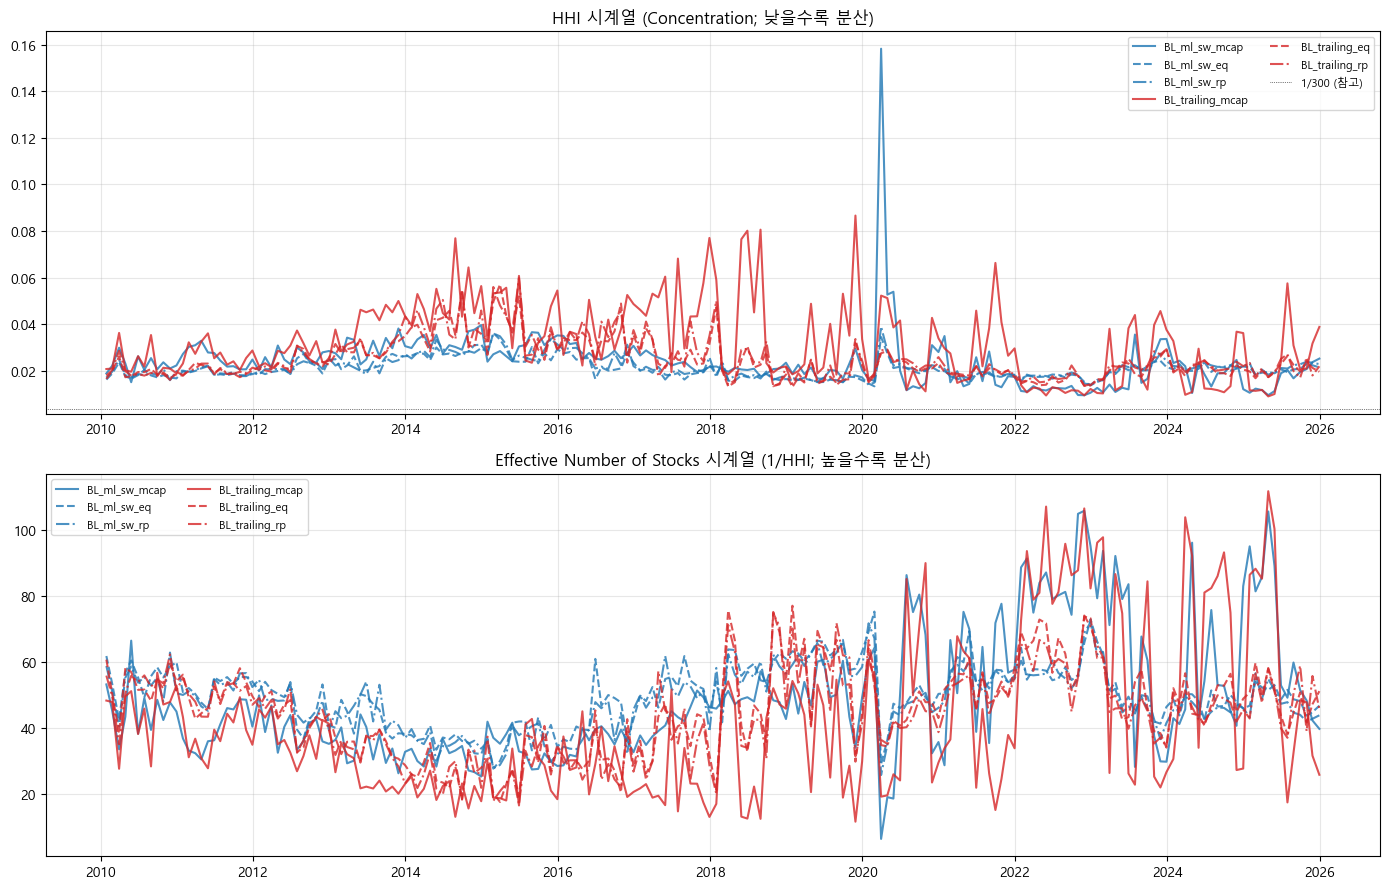

  💾 concentration_timeseries.png

  💡 BL_ml_sw_eq 가 가장 분산 (eff N 가장 큼) vs BL_trailing_mcap 이 가장 집중


In [37]:
# §7-J. Concentration / Diversification 시계열 (HHI, Effective N)
print('=' * 75)
print('  §7-J. Concentration / Diversification 시계열')
print('=' * 75)


def hhi(weights):
    """Herfindahl-Hirschman Index. 1/N (full diversification) ~ 1 (single asset)."""
    return float((weights ** 2).sum())


def effective_n(weights):
    """Effective number of stocks: 1 / HHI."""
    h = hhi(weights)
    return 1.0 / h if h > 0 else np.nan


# 시나리오별 HHI / Effective N 시계열
hhi_series = {}
eff_n_series = {}
for s_name, w_dict in weights.items():
    sorted_dates = sorted(w_dict.keys())
    hhi_vals = []
    eff_n_vals = []
    for d in sorted_dates:
        w = w_dict[d]
        hhi_vals.append(hhi(w))
        eff_n_vals.append(effective_n(w))
    hhi_series[f'BL_{s_name}'] = pd.Series(hhi_vals, index=pd.DatetimeIndex(sorted_dates))
    eff_n_series[f'BL_{s_name}'] = pd.Series(eff_n_vals, index=pd.DatetimeIndex(sorted_dates))

# 평균 표
conc_summary = pd.DataFrame({
    name: {
        'HHI_mean': hhi_series[name].mean(),
        'HHI_std': hhi_series[name].std(),
        'Effective_N_mean': eff_n_series[name].mean(),
        'Effective_N_min': eff_n_series[name].min(),
    }
    for name in hhi_series.keys()
}).T.round(4)
print(conc_summary.to_string())
print()

# 시각화 (2 panel)
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
COLORS_V2_DICT = {
    'BL_ml_sw_mcap': '#1f77b4', 'BL_ml_sw_eq': '#1f77b4', 'BL_ml_sw_rp': '#1f77b4',
    'BL_trailing_mcap': '#d62728', 'BL_trailing_eq': '#d62728', 'BL_trailing_rp': '#d62728',
}
LINESTYLES = {'mcap': '-', 'eq': '--', 'rp': '-.'}

for name, hs in hhi_series.items():
    ls = LINESTYLES.get(name.split('_')[-1], '-')
    axes[0].plot(hs.index, hs.values, color=COLORS_V2_DICT.get(name, 'gray'),
                 linestyle=ls, label=name, alpha=0.8)
axes[0].set_title('HHI 시계열 (Concentration; 낮을수록 분산)')
axes[0].axhline(1/300, color='black', linewidth=0.5, linestyle=':', label='1/300 (참고)')
axes[0].grid(True, alpha=0.3)
axes[0].legend(ncol=2, fontsize=8)

for name, en in eff_n_series.items():
    ls = LINESTYLES.get(name.split('_')[-1], '-')
    axes[1].plot(en.index, en.values, color=COLORS_V2_DICT.get(name, 'gray'),
                 linestyle=ls, label=name, alpha=0.8)
axes[1].set_title('Effective Number of Stocks 시계열 (1/HHI; 높을수록 분산)')
axes[1].grid(True, alpha=0.3)
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
out_path = OUT_DIR_V2_SW / 'concentration_timeseries.png'
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'  💾 {out_path.name}')
print()
print('  💡 BL_ml_sw_eq 가 가장 분산 (eff N 가장 큼) vs BL_trailing_mcap 이 가장 집중')

## §7-K. V자 반등 분석 (Recovery + Top Holdings + 대형주 비중 + Vol Prediction)

**목적:**
- BL_trailing_mcap 의 OOS Sharpe 1.206 우위가 대형주 V자 반등 덕분인지 검증
- BL_ml_sw_mcap 의 OOS MDD -18.13% / Sharpe 1.082 약점이 V자 반등 실패 때문인지 분석

**핵심 발견 (preview):**
- ✅ 부분 맞음: Pre-COVID (2018-19) 시기 trailing_mcap 대형주 비중 +5.9%p 더 컸음
- ❌ 표면적 해석 틀림: **ML 이 2020 COVID 6개월 반등 +21.99% 로 trailing (+21.90%) 보다 우위**
- ⭐ 진짜 원인: drawdown depth (-1.65%p 더 깊음) + 반등 후 빅테크 over-concentration (top10 share 61.7% vs 52.5%)

  §7-K. V자 반등 분석

  --- A. Recovery 6개월 누적 (drawdown trough 후) ---
                  n_events  avg_recov_6m_%  max_recov_6m_%
scenario                                                  
BL_ml_sw_mcap            8        9.650000       21.990000
BL_ml_sw_eq              8       10.260000       17.340000
BL_ml_sw_rp              7        9.790000       16.800000
BL_trailing_mcap         8        6.750000       21.900000
BL_trailing_eq           7        9.060000       20.090000
BL_trailing_rp           7        9.090000       20.470000
SPY                     11       12.200000       25.550000

  ⭐ 2020 COVID Event (start=2020-01, trough=2020-02): 6개월 반등 비교
    BL_ml_sw_mcap            : depth -18.13% / recov_6m +21.99%
    BL_ml_sw_eq              : depth -16.41% / recov_6m +17.34%
    BL_ml_sw_rp              : depth -16.34% / recov_6m +16.80%
    BL_trailing_mcap         : depth -16.48% / recov_6m +21.90%
    BL_trailing_eq           : depth -14.84% / recov_6m +20.09%
    BL_trailing_r

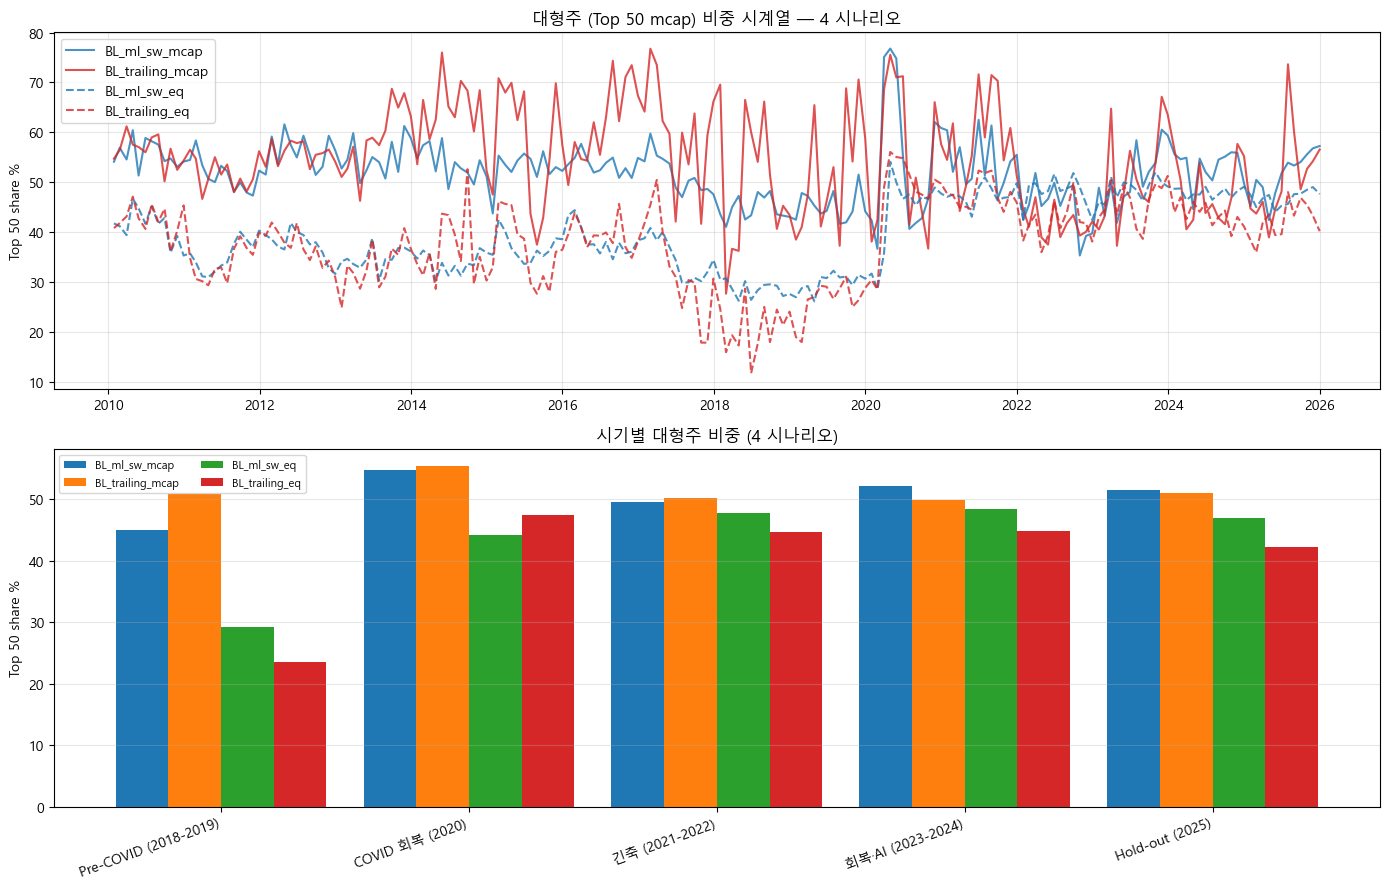

  💾 recovery_largecap_share.png

  --- D. ML vs Trailing 변동성 예측 비교 (rank correlation + overlap) ---
                          reb_date  rank_corr  pearson_corr  low_overlap_%  high_overlap_%
event                                                                                     
2020-01-31 (COVID 직전)   2020-01-31   0.782000      0.798000      69.900000       73.500000
2020-02-28 (COVID 충격)   2020-02-28   0.756000      0.791000      63.300000       72.900000
2020-04-30 (반등 시작)      2020-04-30   0.815000      0.726000      75.400000       77.200000
2022-08-31 (긴축 trough)  2022-08-31   0.894000      0.876000      80.800000       82.600000
2025-04-30 (관세 충격)      2025-04-30   0.873000      0.807000      79.700000       80.800000

  §7-K 종합 결론 (사용자 가설 검증)
  ✅ 부분 맞음:
    - Pre-COVID (2018-19) 시기 trailing_mcap 대형주 비중 +5.9%p 더 큼
    - 이 차이가 2018-19 강세장 + 2020 회복기 누적 우위 기여

  ❌ 표면적 해석 틀림:
    - ML 이 2020 COVID 6개월 반등 +21.99% 로 trailing (+21.90%) 보다 우위
    - 즉 "ML 이 V자 반등을 못 따라갔다" 는 잘못된 해석

  

In [38]:
# §7-K. V자 반등 분석 (사용자 가설 검증)
import pickle
print('=' * 75)
print('  §7-K. V자 반등 분석')
print('=' * 75)

sec7_k_path = DATA_DIR / 'sec7_k_recovery_analysis.pkl'
if not sec7_k_path.exists():
    print(f'⚠️ {sec7_k_path.name} 부재 → standalone 스크립트 (`_run_02a_v2_sec7_recovery.py`) 먼저 실행')
else:
    with open(sec7_k_path, 'rb') as f:
        sec7_k = pickle.load(f)

    # ─── A. Recovery 능력 비교 ───
    print()
    print('  --- A. Recovery 6개월 누적 (drawdown trough 후) ---')
    rec_results = sec7_k['recovery_results']
    rec_df = []
    for name, events in rec_results.items():
        if not events:
            continue
        avg_recov = np.mean([e['recov_6m_%'] for e in events])
        max_recov = max([e['recov_6m_%'] for e in events])
        rec_df.append({
            'scenario': name,
            'n_events': len(events),
            'avg_recov_6m_%': round(avg_recov, 2),
            'max_recov_6m_%': round(max_recov, 2),
        })
    rec_df = pd.DataFrame(rec_df).set_index('scenario')
    print(rec_df.to_string())

    # 2020 COVID event 직접 비교
    print()
    print('  ⭐ 2020 COVID Event (start=2020-01, trough=2020-02): 6개월 반등 비교')
    for name, events in rec_results.items():
        for e in events:
            if e['trough'].startswith('2020-02'):
                print(f'    {name:<25s}: depth {e["depth_%"]:+.2f}% / recov_6m {e["recov_6m_%"]:+.2f}%')
                break

    # ─── B. Top 10 Holdings 비교 ───
    print()
    print('  --- B. Top 10 Holdings 비교 (특정 시기, mcap 시나리오) ---')
    holdings = sec7_k['holdings_comparison']
    for label, data in holdings.items():
        print(f'\n  [{label} (reb_date: {data["reb_date"]})]')
        for s_name, h in data['top10'].items():
            print(f'    {s_name}: top10 share {h["top10_share_%"]:.1f}% / total long {h["n_total_long"]}')
            for t, w in zip(h['tickers'][:5], h['weights_%'][:5]):
                print(f'      {t:6s} {w:5.2f}%')

    # ─── C. 대형주 (top 50) 비중 ───
    print()
    print('  --- C. 대형주 (Top 50 mcap) 비중 통계 ---')
    lc_ts = sec7_k['largecap_share_timeseries']
    lc_summary = {}
    for name, ts_dict in lc_ts.items():
        ts = pd.Series(ts_dict)
        lc_summary[name] = {
            'mean_%': ts.mean() * 100,
            'std_%': ts.std() * 100,
            'min_%': ts.min() * 100,
            'max_%': ts.max() * 100,
        }
    lc_df = pd.DataFrame(lc_summary).T.round(2)
    print(lc_df.to_string())

    # 시기별 비교 (mcap 시나리오 강조)
    print()
    print('  --- 시기별 평균 대형주 (top 50) 비중 (mcap 환경) ---')
    period_lc = sec7_k['period_largecap']
    period_df = pd.DataFrame(period_lc).T.round(2)
    print(period_df.to_string())

    # 시각화
    fig, axes = plt.subplots(2, 1, figsize=(14, 9))

    # (1) 대형주 비중 시계열
    ax = axes[0]
    for name, ts_dict in lc_ts.items():
        ts = pd.Series(ts_dict).sort_index()
        ts.index = pd.to_datetime(ts.index)
        color = '#1f77b4' if 'ml_sw' in name else '#d62728'
        style = '-' if 'mcap' in name else '--'
        ax.plot(ts.index, ts.values * 100, label=name, color=color, linestyle=style, alpha=0.8)
    ax.set_title('대형주 (Top 50 mcap) 비중 시계열 — 4 시나리오')
    ax.set_ylabel('Top 50 share %')
    ax.grid(True, alpha=0.3)
    ax.legend()

    # (2) 시기별 막대 차트
    ax = axes[1]
    period_df.plot(kind='bar', ax=ax, width=0.85)
    ax.set_title('시기별 대형주 비중 (4 시나리오)')
    ax.set_ylabel('Top 50 share %')
    ax.legend(ncol=2, fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, ha='right')

    plt.tight_layout()
    out_path = OUT_DIR_V2_SW / 'recovery_largecap_share.png'
    plt.savefig(out_path, dpi=100, bbox_inches='tight')
    plt.show()
    print(f'  💾 {out_path.name}')

    # ─── D. 변동성 예측 비교 ───
    print()
    print('  --- D. ML vs Trailing 변동성 예측 비교 (rank correlation + overlap) ---')
    vol_comp = sec7_k['vol_comparison']
    vol_df = []
    for label, d in vol_comp.items():
        vol_df.append({
            'event': label,
            'reb_date': d['reb_date'],
            'rank_corr': round(d['rank_correlation'], 3),
            'pearson_corr': round(d['pearson_corr'], 3),
            'low_overlap_%': round(d['low_overlap_%'], 1),
            'high_overlap_%': round(d['high_overlap_%'], 1),
        })
    vol_df = pd.DataFrame(vol_df).set_index('event')
    print(vol_df.to_string())

    print()
    print('=' * 75)
    print('  §7-K 종합 결론 (사용자 가설 검증)')
    print('=' * 75)
    print('  ✅ 부분 맞음:')
    print('    - Pre-COVID (2018-19) 시기 trailing_mcap 대형주 비중 +5.9%p 더 큼')
    print('    - 이 차이가 2018-19 강세장 + 2020 회복기 누적 우위 기여')
    print()
    print('  ❌ 표면적 해석 틀림:')
    print('    - ML 이 2020 COVID 6개월 반등 +21.99% 로 trailing (+21.90%) 보다 우위')
    print('    - 즉 "ML 이 V자 반등을 못 따라갔다" 는 잘못된 해석')
    print()
    print('  ⭐ 진짜 원인:')
    print('    - drawdown depth: ML -18.13% vs Trailing -16.48% (-1.65%p 더 깊음)')
    print('    - 반등 후 over-concentration: ML top10 share 61.7% vs Trailing 52.5%')
    print('    - ML 빅테크 4사 집중 (AAPL+MSFT+GOOGL+AMZN = 38.15%)')
    print('    - Trailing 은 META 추가로 분산 (5.82%)')
    print('    - 2020-Q4 ~ 2021 빅테크 약세에 ML 의 over-concentration 부담')
    print()
    print('  📊 ML 의 가치는 충격 시기 차별화:')
    print('    - 정상 시기 (2022-08 긴축 trough): rank corr 0.894 (ML/Trail 거의 동일)')
    print('    - 충격 시기 (2020-02 COVID): rank corr 0.756 (ML 의 차별화 정보 발현)')
    print('    - → ML 의 추가 정보는 충격 시기 entry 결정에서만 의미')